In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
figure_dir = "./results/drug/figures/"
os.makedirs(figure_dir, exist_ok=True)

In [3]:
pert_type = 'drug'  # 'crispri' or 'crisprko'

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'DMSO')
slk.configs.set_config('pert_key', 'drug')
slk.configs.set_config('treatment_key', 'tcell_treatment')
slk.configs.set_config('untreated_label', 'NoT')
slk.configs.show()
#slk.configs.reset_config()
slk.configs.get_config('ntc_label')


ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated
ntc_label       = DMSO
pert_key        = drug
treatment_key   = tcell_treatment
untreated_label = NoT


'DMSO'

In [8]:
concentration  = '10'
tcdg = 1000
data = sc.read_h5ad(f"../../datasets/gbm/bt333_degs_tcell_{concentration}_{tcdg}.h5ad")
data.obs

,P7,P5,sample,n.umi,cell_ID,RT,Lig,new_cell,oligo,hash_umis,total_hash_umis_per_cell_ID,top_to_second_best_ratio,treatment,log10.umi,percent_mito,experiment,drug,concentration,tcell_treatment
F01_A06_RT_BC_100_Lig_BC_12,F01,A06,BT333_Tcells,5598.0,F01_A06_RT_BC_100_Lig_BC_12,RT_BC_100,Lig_BC_12,A06_RT_BC_100_Lig_BC_12,EX2P13_Zabedosertib_1_NoT_R1_02B04,30,43,30.000000,EX2P13_Zabedosertib_1_NoT,3.748033,0.0,EX2P13,Zabedosertib,1,NoT
F01_A06_RT_BC_100_Lig_BC_15,F01,A06,BT333_Tcells,1520.0,F01_A06_RT_BC_100_Lig_BC_15,RT_BC_100,Lig_BC_15,A06_RT_BC_100_Lig_BC_15,Ex2P11_SGCAAK11_1_0.5T_R3_01F06,6,24,3.000000,Ex2P11_SGCAAK11_1_0.5T,3.181844,0.0,Ex2P11,SGCAAK11,1,0.5T
F01_A06_RT_BC_100_Lig_BC_20,F01,A06,BT333_Tcells,2339.0,F01_A06_RT_BC_100_Lig_BC_20,RT_BC_100,Lig_BC_20,A06_RT_BC_100_Lig_BC_20,Ex2P11_STK16IN1_0.1_0.5T_R1_01C02,11,43,5.500000,Ex2P11_STK16IN1_0.1_0.5T,3.369030,0.0,Ex2P11,STK16IN1,0.1,0.5T
F01_A06_RT_BC_100_Lig_BC_21,F01,A06,BT333_Tcells,9603.0,F01_A06_RT_BC_100_Lig_BC_21,RT_BC_100,Lig_BC_21,A06_RT_BC_100_Lig_BC_21,Ex2P11_Abemaciclibmesylate_0.01_0.5T_R2_01H01,61,78,30.500000,Ex2P11_Abemaciclibmesylate_0.01_0.5T,3.982407,0.0,Ex2P11,Abemaciclibmesylate,0.01,0.5T
F01_A06_RT_BC_100_Lig_BC_23,F01,A06,BT333_Tcells,913.0,F01_A06_RT_BC_100_Lig_BC_23,RT_BC_100,Lig_BC_23,A06_RT_BC_100_Lig_BC_23,EX2P13_Zabedosertib_0.01_NoT_R1_02D04,16,45,8.000000,EX2P13_Zabedosertib_0.01_NoT,2.960471,0.0,EX2P13,Zabedosertib,0.01,NoT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F12_H06_RT_BC_99_Lig_BC_60,F12,H06,BT333_Tcells,777.0,F12_H06_RT_BC_99_Lig_BC_60,RT_BC_99,Lig_BC_60,H06_RT_BC_99_Lig_BC_60,EX1P11_Taletrectinib_0.01_0.5T_R3_04H05,6,17,6.000000,EX1P11_Taletrectinib_0.01_0.5T,2.890421,0.0,EX1P11,Taletrectinib,0.01,0.5T
F12_H06_RT_BC_99_Lig_BC_63,F12,H06,BT333_Tcells,1451.0,F12_H06_RT_BC_99_Lig_BC_63,RT_BC_99,Lig_BC_63,H06_RT_BC_99_Lig_BC_63,EX1P11_Abemaciclibmesylate_0.01_NoT_R3_04D10,53,329,4.818182,EX1P11_Abemaciclibmesylate_0.01_NoT,3.161667,0.0,EX1P11,Abemaciclibmesylate,0.01,NoT
F12_H06_RT_BC_99_Lig_BC_86,F12,H06,BT333_Tcells,1033.0,F12_H06_RT_BC_99_Lig_BC_86,RT_BC_99,Lig_BC_86,H06_RT_BC_99_Lig_BC_86,EX1P11_Tyrphostin9_0.01_0.5T_R2_04D08,33,111,2.750000,EX1P11_Tyrphostin9_0.01_0.5T,3.014100,0.0,EX1P11,Tyrphostin9,0.01,0.5T
F12_H06_RT_BC_99_Lig_BC_88,F12,H06,BT333_Tcells,1693.0,F12_H06_RT_BC_99_Lig_BC_88,RT_BC_99,Lig_BC_88,H06_RT_BC_99_Lig_BC_88,Ex2P11_SGCAAK11_0.01_0.5T_R3_01H06,10,17,10.000000,Ex2P11_SGCAAK11_0.01_0.5T,3.228657,0.0,Ex2P11,SGCAAK11,0.01,0.5T


In [9]:
data.obs['concentration']

F01_A06_RT_BC_100_Lig_BC_12       1
F01_A06_RT_BC_100_Lig_BC_15       1
F01_A06_RT_BC_100_Lig_BC_20     0.1
F01_A06_RT_BC_100_Lig_BC_21    0.01
F01_A06_RT_BC_100_Lig_BC_23    0.01
                               ... 
F12_H06_RT_BC_99_Lig_BC_60     0.01
F12_H06_RT_BC_99_Lig_BC_63     0.01
F12_H06_RT_BC_99_Lig_BC_86     0.01
F12_H06_RT_BC_99_Lig_BC_88     0.01
F12_H06_RT_BC_99_Lig_BC_95       10
Name: concentration, Length: 106721, dtype: category
Categories (5, object): ['0', '0.01', '0.1', '1', '10']

In [10]:
# remove na from drug column
data = data[~data.obs['drug'].isna()].copy()
data = data[
    (data.obs['concentration'] == concentration) | (data.obs['drug'] == 'DMSO')
].copy()

In [13]:
data.obs.tcell_treatment

F01_A06_RT_BC_100_Lig_BC_54     NoT
F01_A06_RT_BC_100_Lig_BC_85    0.5T
F01_A06_RT_BC_100_Lig_BC_86    0.5T
F01_A06_RT_BC_100_Lig_BC_96    0.5T
F01_A06_RT_BC_101_Lig_BC_16    0.5T
                               ... 
F12_H06_RT_BC_98_Lig_BC_65      NoT
F12_H06_RT_BC_98_Lig_BC_83      NoT
F12_H06_RT_BC_99_Lig_BC_42     0.5T
F12_H06_RT_BC_99_Lig_BC_47      NoT
F12_H06_RT_BC_99_Lig_BC_95      NoT
Name: tcell_treatment, Length: 35511, dtype: category
Categories (2, object): ['0.5T', 'NoT']

In [14]:
slk.pp.slk_prepare_data(data, pert_key="drug", ntc_label="DMSO", inplace=True, treatment_key="tcell_treatment", untreated_label="NoT", force=True)

AnnData object with n_obs × n_vars = 35511 × 2894
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'experiment', 'drug', 'concentration', 'tcell_treatment'
    var: 'features'

In [15]:
data.obs

,P7,P5,sample,n.umi,cell_ID,RT,Lig,new_cell,oligo,hash_umis,total_hash_umis_per_cell_ID,top_to_second_best_ratio,treatment,log10.umi,percent_mito,experiment,drug,concentration,tcell_treatment
F01_A06_RT_BC_100_Lig_BC_54,F01,A06,BT333_Tcells,3746.0,F01_A06_RT_BC_100_Lig_BC_54,RT_BC_100,Lig_BC_54,A06_RT_BC_100_Lig_BC_54,EX1P11_DMSO_0_NoT_R15_04E11,6,7,6.000000,EX1P11_DMSO_0_NoT,3.573568,0.0,EX1P11,DMSO,0,NoT
F01_A06_RT_BC_100_Lig_BC_85,F01,A06,BT333_Tcells,1158.0,F01_A06_RT_BC_100_Lig_BC_85,RT_BC_100,Lig_BC_85,A06_RT_BC_100_Lig_BC_85,EX1P11_CP673451_10_0.5T_R1_04A04,7,14,3.500000,EX1P11_CP673451_10_0.5T,3.063709,0.0,EX1P11,CP673451,10,0.5T
F01_A06_RT_BC_100_Lig_BC_86,F01,A06,BT333_Tcells,625.0,F01_A06_RT_BC_100_Lig_BC_86,RT_BC_100,Lig_BC_86,A06_RT_BC_100_Lig_BC_86,Ex2P11_PF06260933_10_0.5T_R1_01A05,13,17,13.000000,Ex2P11_PF06260933_10_0.5T,2.795880,0.0,Ex2P11,PF06260933,10,0.5T
F01_A06_RT_BC_100_Lig_BC_96,F01,A06,BT333_Tcells,2568.0,F01_A06_RT_BC_100_Lig_BC_96,RT_BC_100,Lig_BC_96,A06_RT_BC_100_Lig_BC_96,Ex2P11_ALWII4127_10_0.5T_R3_01E08,11,14,11.000000,Ex2P11_ALWII4127_10_0.5T,3.409595,0.0,Ex2P11,ALWII4127,10,0.5T
F01_A06_RT_BC_101_Lig_BC_16,F01,A06,BT333_Tcells,1667.0,F01_A06_RT_BC_101_Lig_BC_16,RT_BC_101,Lig_BC_16,A06_RT_BC_101_Lig_BC_16,EX1P11_Laduviglusib_10_0.5T_R1_04A06,4,9,4.000000,EX1P11_Laduviglusib_10_0.5T,3.221936,0.0,EX1P11,Laduviglusib,10,0.5T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F12_H06_RT_BC_98_Lig_BC_65,F12,H06,BT333_Tcells,2190.0,F12_H06_RT_BC_98_Lig_BC_65,RT_BC_98,Lig_BC_65,H06_RT_BC_98_Lig_BC_65,Ex2P11_DMSO_0_NoT_R1_01A08,31,38,31.000000,Ex2P11_DMSO_0_NoT,3.340444,0.0,Ex2P11,DMSO,0,NoT
F12_H06_RT_BC_98_Lig_BC_83,F12,H06,BT333_Tcells,4523.0,F12_H06_RT_BC_98_Lig_BC_83,RT_BC_98,Lig_BC_83,H06_RT_BC_98_Lig_BC_83,Ex2P11_DMSO_0_NoT_R3_01C08,92,276,10.222222,Ex2P11_DMSO_0_NoT,3.655427,0.0,Ex2P11,DMSO,0,NoT
F12_H06_RT_BC_99_Lig_BC_42,F12,H06,BT333_Tcells,4863.0,F12_H06_RT_BC_99_Lig_BC_42,RT_BC_99,Lig_BC_42,H06_RT_BC_99_Lig_BC_42,EX1P11_BAY1217389_10_0.5T_R1_04A02,6,8,6.000000,EX1P11_BAY1217389_10_0.5T,3.686904,0.0,EX1P11,BAY1217389,10,0.5T
F12_H06_RT_BC_99_Lig_BC_47,F12,H06,BT333_Tcells,869.0,F12_H06_RT_BC_99_Lig_BC_47,RT_BC_99,Lig_BC_47,H06_RT_BC_99_Lig_BC_47,EX2P13_ALWII4127_10_NoT_R2_02E03,33,62,16.500000,EX2P13_ALWII4127_10_NoT,2.939020,0.0,EX2P13,ALWII4127,10,NoT


In [ ]:
slk.pp.treat_effect(
    data,
    label_col = "drug",
    control_label = 'DMSO',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 11/11 [00:01<00:00,  8.24it/s]


In [ ]:
import warnings

c_key = slk.configs.get_config('treatment_key')
c_ntc_key = slk.configs.get_config('untreated_label')
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

data_untreated = data[data.obs[c_key] == c_ntc_key].copy()
sc.pp.normalize_total(data_untreated, target_sum=1e4)
sc.pp.log1p(data_untreated)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sc.tl.rank_genes_groups(
        data_untreated,
        groupby=p_key,
        reference=NTC,
        method='wilcoxon',
        key_added='degs',
        pts=True,
    )

degs_df = sc.get.rank_genes_groups_df(data_untreated, group=None, key='degs')
degs_df = degs_df.rename(columns={'group': 'perturbation', 'names': 'gene'})
degs_df = degs_df[degs_df['perturbation'] != NTC].reset_index(drop=True)

SIG_PADJ  = 0.05
SIG_LOGFC = 0.25

sig   = degs_df[(degs_df['pvals_adj'] < SIG_PADJ) & (degs_df['logfoldchanges'].abs() > SIG_LOGFC)]
n_sig = sig.groupby('perturbation').size().rename('n_sig_degs')

print(f"Condition: {c_key} == {c_ntc_key}  ({data_untreated.n_obs} cells)")
print(f"Significant DEGs  (padj < {SIG_PADJ}, |logFC| > {SIG_LOGFC}):")
print(f"  Perturbations with ≥1 DEG : {(n_sig > 0).sum()} / {len(n_sig)}")
print(f"  Median DEGs per pert      : {n_sig.median():.0f}")
print(f"  Max DEGs                  : {n_sig.max()}  ({n_sig.idxmax()})")
print()
print(n_sig.sort_values(ascending=False).to_string())


Condition: tcell_treatment == NoT  (14671 cells)
Significant DEGs  (padj < 0.05, |logFC| > 0.25):
  Perturbations with ≥1 DEG : 11 / 11
  Median DEGs per pert      : 269
  Max DEGs                  : 3022  (CP673451)

perturbation
CP673451               3022
BAY1217389             1482
Tyrphostin9             575
Abemaciclibmesylate     470
Laduviglusib            417
ALWII4127               269
SGCAAK11                 90
PF06260933               33
STK16IN1                 23
Taletrectinib            23
Zabedosertib              2


In [22]:
data

AnnData object with n_obs × n_vars = 35511 × 2894
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'experiment', 'drug', 'concentration', 'tcell_treatment'
    var: 'features'
    uns: 'treat_effect'

In [24]:
# Check for NaN/Inf in expression matrix
print(f"Data shape: {data.shape}")
X = data.X.toarray() if hasattr(data.X, 'toarray') else data.X

n_nan = np.isnan(X).sum()
n_inf = np.isinf(X).sum()
print(f"NaN values in X: {n_nan}")
print(f"Inf values in X: {n_inf}")

if n_nan > 0 or n_inf > 0:
    print("Cleaning expression matrix...")
    # Replace NaN with 0 and clip Inf values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    data.X = X
    print("Expression matrix cleaned!")

# Check data stats
print(f"X min: {data.X.min()}, max: {data.X.max()}")
print(f"Unique drugs: {data.obs['drug'].nunique()}")

Data shape: (35511, 2894)
NaN values in X: 0
Inf values in X: 0
X min: 0.0, max: 3628.0
Unique drugs: 12


In [25]:
# DIAGNOSE: Check condition distribution
print("=== Condition Distribution ===")
print(f"\nTotal cells: {len(data)}")
print(f"\nUnique values in 'tcell_treatment':")
print(data.obs['tcell_treatment'].value_counts())

print(f"\n\nDMSO cells by condition:")
dmso_data = data[data.obs['drug']=='DMSO']
print(dmso_data.obs['tcell_treatment'].value_counts())

print(f"\n\nNon-DMSO cells by condition:")
non_dmso_data = data[data.obs['drug']!='DMSO']
print(non_dmso_data.obs['tcell_treatment'].value_counts())

# what the count for all drugs including DMSO
print(f"\n\nAll cells by drug:")
print(data.obs['drug'].value_counts())  

print(f"\n\n=== CRITICAL CHECK ===")
if len(dmso_data) == 0:
    print("❌ ERROR: NO DMSO CELLS FOUND!")
    print("   The model cannot train without control cells.")
else:
    print(f"✅ Found {len(dmso_data)} DMSO cells")
    
# Check if all conditions have DMSO
all_conditions = data.obs['tcell_treatment'].unique()
for cond in all_conditions:
    dmso_count = len(data[(data.obs['drug']=='DMSO') & (data.obs['tcell_treatment']==cond)])
    print(f"   Condition '{cond}': {dmso_count} DMSO cells")

=== Condition Distribution ===

Total cells: 35511

Unique values in 'tcell_treatment':
tcell_treatment
0.5T    20840
NoT     14671
Name: count, dtype: int64


DMSO cells by condition:
tcell_treatment
0.5T    9253
NoT     8037
Name: count, dtype: int64


Non-DMSO cells by condition:
tcell_treatment
0.5T    11587
NoT      6634
Name: count, dtype: int64


All cells by drug:
drug
DMSO                   17290
Zabedosertib            2555
PF06260933              2338
Laduviglusib            2125
STK16IN1                2083
SGCAAK11                1881
ALWII4127               1473
Taletrectinib           1377
Abemaciclibmesylate     1333
CP673451                1323
BAY1217389               903
Tyrphostin9              830
Name: count, dtype: int64


=== CRITICAL CHECK ===
✅ Found 17290 DMSO cells
   Condition 'NoT': 8037 DMSO cells
   Condition '0.5T': 9253 DMSO cells


Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [07:01<00:00,  1.19it/s, ATE=0.7377, CE=0.1745, ELBO=1838.5682, KLw=1.00, R2_ntc=0.7498, R2_p=0.7532, acc=0.938, pi25=0.02, pi99=1.00, tau=0.300]


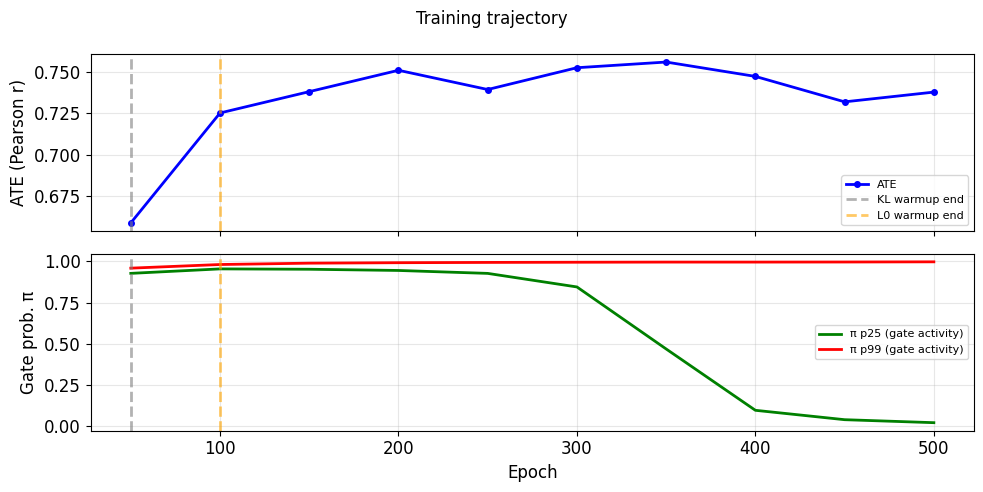

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, 
                            batch_size=4096,
                             num_workers=0, 
                             device=device, 
                             num_epochs=500,
                             use_conditions=True,
                             validate_every=50,
                             debug=True,
                            #  lr=1e-2,
                            #  gate_init_p=0.1
                             l0_lambda=300,
                            #  ce_lambda=1e2,
                             lr=1e-2,
                             patience=500,
                             rho_init=False,
                             ntc_lambda=1.0,
                            #  cov_lambda=1e-1,
                            #  prior_cond_ridge=1e-1
                            #  n_epochs_kl_warmup=10,
                             latent_dim=8
                             )

# H_lambda, the lower more stable. 

In [21]:
import datetime
    
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

slk.tl.save_results(results, f'../data/{pert_type}_model_{timestamp}.pth')

In [22]:
print(f"Model saved to ../data/{pert_type}_model_{timestamp}.pth")

Model saved to ../data/drug_model_20260508_140606.pth


In [23]:
data

AnnData object with n_obs × n_vars = 35511 × 2894
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'experiment', 'drug', 'concentration', 'tcell_treatment'
    var: 'features'
    uns: 'treat_effect'

In [69]:
#model = slk.tl.load_results('/home/user/Documents/Githubs/PerturbVAE/sherlock/notebooks/data/drug_model_20251210_000125.pth')

model = model = results['model']
#model = slk.tl.load_results('/home/user/Documents/Githubs/PerturbVAE_sherlock_benchmarking/sherlock/notebooks/data/drug_model_20260429_215219.pth')


In [66]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [70]:
data.uns['results'].keys()

dict_keys(['z_corr', 'z_perts', 'z_embed', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions'])

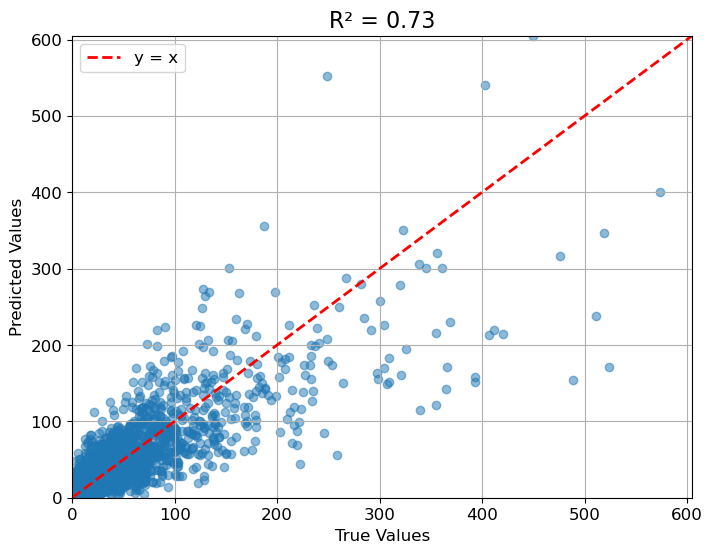

In [27]:
data.X = data.X.toarray()
slk.pl.plot_r2(data)

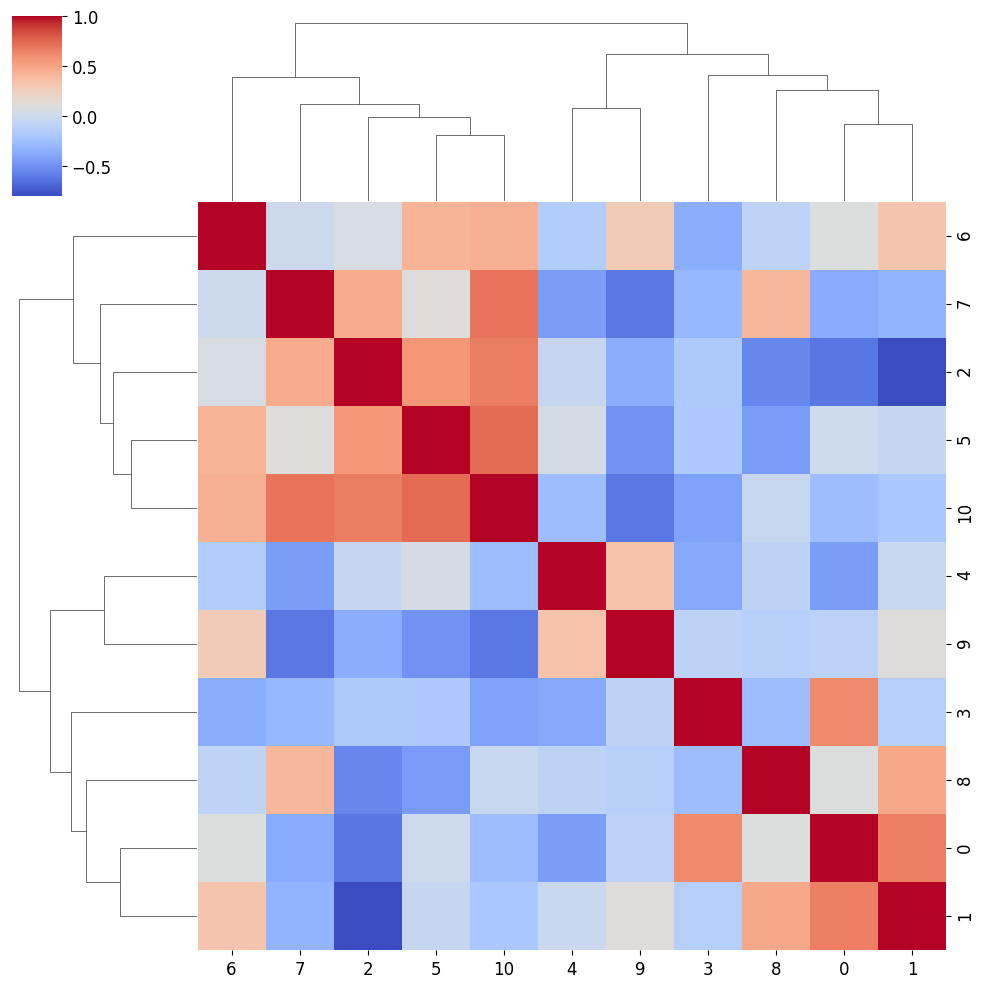

In [71]:
slk.pl.plot_corr(data)

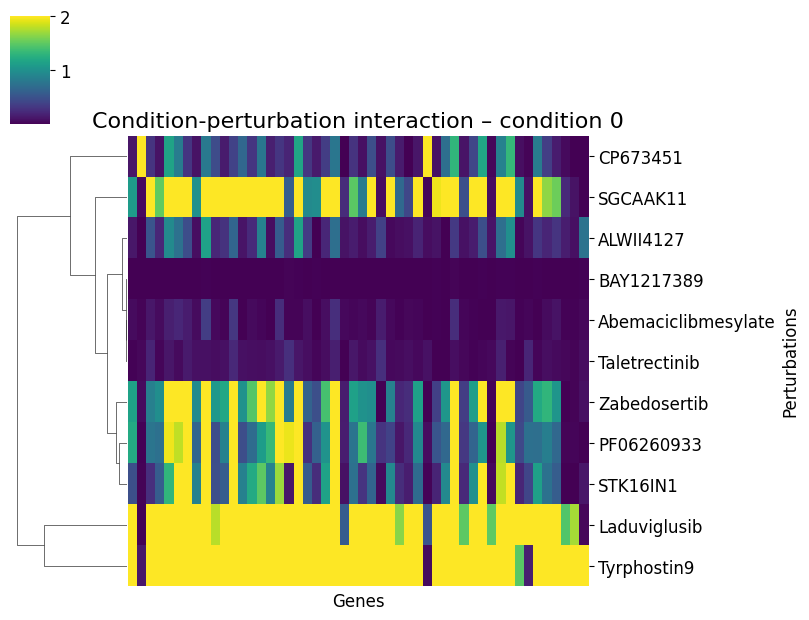

In [56]:
slk.pl.plot_ev(data, cmax=2, top_n=50)

In [33]:
slk.tl.ev_sig(data, cond_idx=0)

In [34]:
slk.tl.ev_sig(data, cond_idx=1)

In [35]:
# Useful dataframe that plot_ev_sig uses internally
slk.pl.make_ev_long_df(data, cond_idx=0, uns_key="results")

,pert,gene,ev,pval,qval
0,ALWII4127,A2M,0.016352,5.203156e-01,7.663796e-01
1,ALWII4127,AACS,0.021028,4.433941e-01,7.663796e-01
2,ALWII4127,AAK1,0.056756,5.267358e-02,2.019038e-01
3,ALWII4127,AARS,0.765050,1.000000e-300,1.929333e-299
4,ALWII4127,ABAT,0.561617,1.000000e-300,1.929333e-299
...,...,...,...,...,...
31829,Zabedosertib,ZNRF3,0.003709,6.644443e-01,7.641148e-01
31830,Zabedosertib,ZRANB3,0.026332,8.464103e-02,3.073415e-01
31831,Zabedosertib,ZXDC,0.004990,6.265613e-01,7.641148e-01
31832,Zabedosertib,ZYG11B,0.018879,2.171714e-01,6.254933e-01


In [36]:
# Useful dataframe that plot_ev_sig uses internally
slk.pl.make_ev_long_df(data, cond_idx=1, uns_key="results")

,pert,gene,ev,pval,qval
0,ALWII4127,A2M,0.113797,3.985534e-02,1.495997e-01
1,ALWII4127,AACS,0.009699,6.954381e-01,7.649238e-01
2,ALWII4127,AAK1,0.063309,2.564071e-01,6.795258e-01
3,ALWII4127,AARS,1.128559,1.000000e-300,1.753939e-299
4,ALWII4127,ABAT,2.290936,1.000000e-300,1.753939e-299
...,...,...,...,...,...
31829,Zabedosertib,ZNRF3,0.006082,6.672940e-01,7.701111e-01
31830,Zabedosertib,ZRANB3,0.135193,6.015514e-10,1.048729e-08
31831,Zabedosertib,ZXDC,0.008717,6.177285e-01,7.701111e-01
31832,Zabedosertib,ZYG11B,0.034684,1.561893e-01,5.263866e-01


Plotting condition 0: NoT
  -> Saved to ./results/drug/figures/: figure_ev_sig_10um_1000_NoT.svg/png/pdf + _qvalues.csv


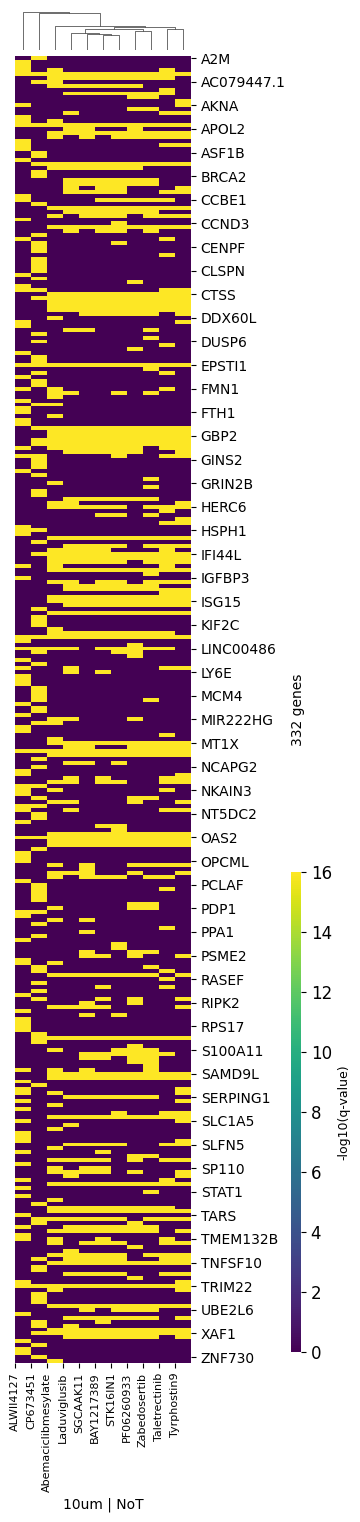

Plotting condition 1: 0.5T
  -> Saved to ./results/drug/figures/: figure_ev_sig_10um_1000_0.5T.svg/png/pdf + _qvalues.csv


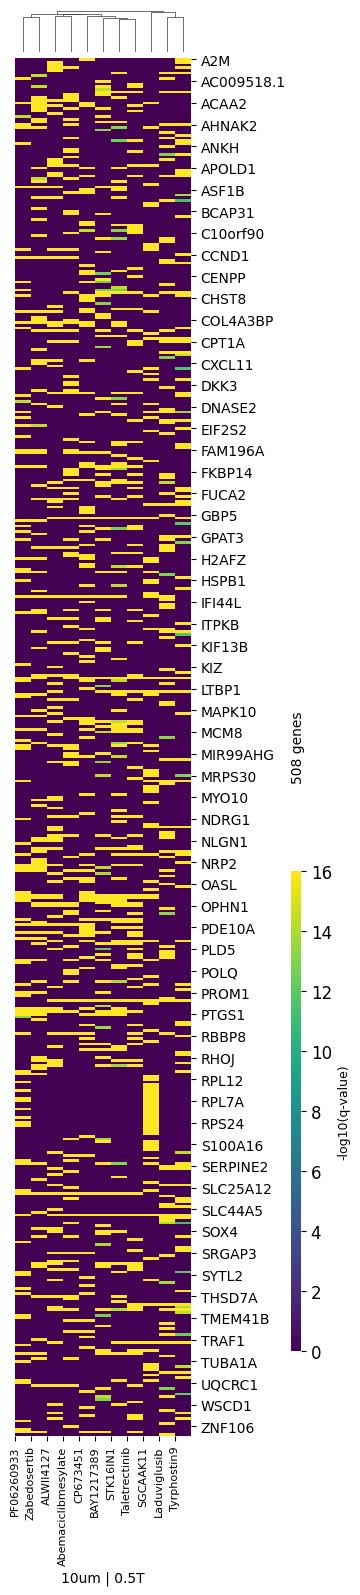

In [37]:
# --- Publication-ready wrapper: all conditions ---
# figure_dir is defined in cell 1
FIGSIZE = (2, 16)
DENDRO_RATIO = 0.03

from unittest.mock import patch

cond_labels = data.uns['results']['conditions']
n_conds = len(data.uns['results']['counterfactual_effect_size'])

_orig_clustermap = sns.clustermap

def _make_patched(captured):
    def _patched_clustermap(*args, **kwargs):
        data_T = args[0].T
        args = (data_T,) + args[1:]
        row_cluster = kwargs.pop('row_cluster', True)
        col_cluster = kwargs.pop('col_cluster', False)
        kwargs['row_cluster'] = col_cluster
        kwargs['col_cluster'] = row_cluster
        kwargs['figsize'] = FIGSIZE
        kwargs['dendrogram_ratio'] = (0.1, DENDRO_RATIO)
        kwargs['cmap'] = 'viridis'
        kwargs['linewidths'] = 0
        kwargs['cbar_pos'] = (1.38, 0.15, 0.05, 0.3)
        g = _orig_clustermap(*args, **kwargs)
        captured['g'] = g
        return g
    return _patched_clustermap

for cond_idx in range(n_conds):
    cond_label = cond_labels[cond_idx]
    print(f'Plotting condition {cond_idx}: {cond_label}')
    _captured = {}
    with patch.object(sns, 'clustermap', _make_patched(_captured)):
        with patch.object(plt, 'show', lambda: None):
            slk.pl.plot_ev_sig(
                data,
                cond_idx=cond_idx,
                uns_key='results',
                alpha=0.05,
                top_n_genes=100,
                min_sig_genes=3,
                cluster_rows=True,
                cluster_cols=False,
                use_clustermap=True,
            )
    if 'g' not in _captured:
        print(f'  -> No significant results, skipping.')
        continue
    g = _captured['g']
    n_genes = g.data2d.shape[0]
    g.ax_heatmap.set_title('')
    g.ax_heatmap.set_xticks(range(g.data2d.shape[1]))
    g.ax_heatmap.set_xticklabels(list(g.data2d.columns), fontsize=8, rotation=90)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10, rotation=0)
    g.ax_heatmap.set_xlabel(f'{concentration}um | {cond_label}', fontsize=10)
    g.ax_heatmap.set_ylabel(f'{n_genes} genes', fontsize=10)
    g.cax.set_ylabel('-log10(q-value)', fontsize=9)
    pos = g.ax_heatmap.get_position()
    new_x0 = 0.0
    new_width = 0.88
    g.ax_heatmap.set_position([new_x0, pos.y0, new_width, pos.height])
    dcol = g.ax_col_dendrogram.get_position()
    g.ax_col_dendrogram.set_position([new_x0, dcol.y0, new_width, dcol.height])
    save_name = f'figure_ev_sig_{concentration}um_{tcdg}_{cond_label}'
    for ext in ('svg', 'png', 'pdf'):
        g.fig.savefig(os.path.join(figure_dir, f'{save_name}.{ext}'), dpi=300, bbox_inches='tight')
    # Save q-value matrix as CSV (perturbation x gene)
    qval_matrix = 10 ** (-g.data2d)
    qval_matrix.index.name = 'perturbation'
    qval_matrix.columns.name = 'gene'
    qval_matrix.to_csv(os.path.join(figure_dir, f'{save_name}_qvalues.csv'))
    print(f'  -> Saved to {figure_dir}: {save_name}.svg/png/pdf + _qvalues.csv')
    plt.show()


In [35]:
# Get condition information
cond_labels = data.uns['results']['conditions']
n_conds = len(data.uns['results']['counterfactual_effect_size'])

# Save filtered significant results per condition
for cond_idx in range(n_conds):
    cond_label = cond_labels[cond_idx]
    slk.tl.ev_sig(data, cond_idx=cond_idx)
    # Get long-form data for this condition
    df_sig = slk.pl.make_ev_long_df(data, cond_idx=cond_idx)
    
    # Filter for significant q-values only
    df_sig = df_sig[df_sig["qval"] < 0.05]
    
    # Skip if no significant results
    if df_sig.empty:
        print(f"Condition {cond_idx} ({cond_label}): No significant results (q < 0.05)")
        continue
    
    # Create filename
    save_name = f'filtered_significant_{pert_type}_{concentration}_{cond_label}.csv'
    save_path = os.path.join(figure_dir, save_name)
    
    # Save to CSV
    df_sig.to_csv(save_path, index=False)
    
    print(f"Condition {cond_idx} ({cond_label}): {len(df_sig)} significant pairs saved")
    print(f"  → {save_path}\n")

Condition 0 (NoT): 6617 significant pairs saved
  → /home/user/Documents/Githubs/PerturbVAE/sherlock/results/figures/filtered_significant_drug_10_NoT.csv

Condition 1 (0.5T): 6580 significant pairs saved
  → /home/user/Documents/Githubs/PerturbVAE/sherlock/results/figures/filtered_significant_drug_10_0.5T.csv



In [36]:
# Genes significantly regulated by both ALWII4127 (AL) and CP673451 (CP)
# Uses the ev_sig results already computed for cond_idx=1

alpha = 0.05
cond_idx = 1

df_ev = slk.pl.make_ev_long_df(data, cond_idx=cond_idx, uns_key='results')
df_ev_sig = df_ev[df_ev['qval'] < alpha]

genes_AL = set(df_ev_sig[df_ev_sig['pert'] == 'ALWII4127']['gene'])
genes_CP = set(df_ev_sig[df_ev_sig['pert'] == 'CP673451']['gene'])

shared_genes = genes_AL & genes_CP

print(f'Significant genes in ALWII4127 : {len(genes_AL)}')
print(f'Significant genes in CP673451  : {len(genes_CP)}')
print(f'Shared genes                   : {len(shared_genes)}')
print()

# Show shared genes with EV and q-value for each drug
df_shared = df_ev_sig[df_ev_sig['gene'].isin(shared_genes) &
                       df_ev_sig['pert'].isin(['ALWII4127', 'CP673451'])]
df_shared = (df_shared[['pert', 'gene', 'ev', 'qval']]
             .pivot(index='gene', columns='pert', values=['ev', 'qval'])
             .sort_values(('ev', 'ALWII4127'), ascending=False))
df_shared.columns = ['ev_AL', 'ev_CP', 'qval_AL', 'qval_CP']
print(df_shared.to_string())
df_shared.to_csv(os.path.join(figure_dir, f'shared_AL_CP_{concentration}um_with_T_cell_conditions.csv'))


Significant genes in ALWII4127 : 571
Significant genes in CP673451  : 590
Shared genes                   : 234

               ev_AL     ev_CP        qval_AL        qval_CP
gene                                                        
TMEM132B    5.406610  0.223617  1.879221e-299   1.073734e-05
APOE        4.551847  1.908026  1.879221e-299  1.303604e-299
NNMT        2.254260  0.313563  1.879221e-299   3.295763e-11
OPCML       1.788839  0.423389  1.879221e-299  1.303604e-299
TRIB3       1.635040  0.540197  1.879221e-299  1.303604e-299
HS6ST1      1.386345  0.377047  1.879221e-299  1.303604e-299
HLA-DQA1    1.349481  0.762094  1.879221e-299  1.303604e-299
GABBR2      1.265452  0.474308  1.879221e-299  1.303604e-299
CTNNA3      1.187096  0.274229  1.879221e-299   1.515910e-08
OLIG1       1.153559  0.164731  1.879221e-299   3.294329e-03
NEBL        1.123036  0.145017  1.879221e-299   1.422751e-02
MVP         0.988887  0.317366  1.879221e-299   1.759737e-11
OAS2        0.976996  0.737725  1.

In [37]:
# # Genes significantly regulated by BOTH AL and CP, but NO other drug

# # Significant genes per drug (all drugs)
# genes_per_drug = df_ev_sig.groupby('pert')['gene'].apply(set).to_dict()

# genes_other = set()
# for drug, genes in genes_per_drug.items():
#     if drug not in ('ALWII4127', 'CP673451'):
#         genes_other |= genes

# exclusive_genes = shared_genes - genes_other

# print(f'Shared AL+CP genes          : {len(shared_genes)}')
# print(f'Also in other drugs         : {len(shared_genes & genes_other)}')
# print(f'Exclusive to AL+CP only     : {len(exclusive_genes)}')
# print()

# df_exclusive = df_ev_sig[df_ev_sig['gene'].isin(exclusive_genes) &
#                           df_ev_sig['pert'].isin(['ALWII4127', 'CP673451'])]
# df_exclusive = (df_exclusive[['pert', 'gene', 'ev', 'qval']]
#                 .pivot(index='gene', columns='pert', values=['ev', 'qval'])
#                 .sort_values(('ev', 'ALWII4127'), ascending=False))
# df_exclusive.columns = ['ev_AL', 'ev_CP', 'qval_AL', 'qval_CP']
# print(df_exclusive.to_string())
# df_exclusive.to_csv(os.path.join(figure_dir, f'exclusive_AL_CP_{concentration}um_with_T_cell_conditions.csv'))


#immune / antigen-presentation genes
These are the easiest to interpret and strongest for your story.
STAT1 — core interferon-response transcription factor
HLA-E — nonclassical MHC-I, immune recognition
UBE2L6 — interferon-inducible ubiquitin-conjugating enzyme
LY6E — interferon-stimulated / immune-modulatory gene
PSME1 — immunoproteasome/antigen-processing related
DDX60 — antiviral innate immune sensor/ISG
HLA-DMA — MHC-II peptide loading
ERAP1 — trims peptides for MHC-I presentation
PSMB9 — immunoproteasome subunit
HLA-C — classical MHC-I
PSMB8 — immunoproteasome subunit

#Adhesion / membrane / tumor–immune interface
These are also very relevant biologically.
EMP1 — membrane protein, often linked to invasive/mesenchymal states
ITGA6 — integrin alpha-6, adhesion / stem-like and invasive behavior
ACTN1 — actin cytoskeleton / adhesion
LOXL1 — extracellular matrix remodeling
SVIL — actin-associated cytoskeletal protein
SH3D19 — membrane trafficking / signaling scaffold
LSAMP — cell adhesion molecule
COL6A1 — ECM / mesenchymal matrix
CAVIN1 — caveolae / membrane organization
AHNAK — large scaffold protein, membrane/cytoskeleton
ITGAV — integrin alpha-V, ECM interaction / migration
ANXA2 — membrane organization, invasion, fibrinolysis

#Cytoskeleton / trafficking / migration
CLASP2 — microtubule stabilization
CLIP1 — microtubule-binding trafficking protein
NAV2 — cytoskeletal guidance / migration-related
EPN2 — endocytosis
TMSB10 — actin dynamics
ARHGEF7 — Rho GTPase signaling / cytoskeleton
ARHGEF9 — Rho signaling scaffold
CALCOCO2 — autophagy cargo receptor, also stress response

#Neural / lineage / glioma-state genes
These are important because they suggest tumor-state remodeling, not just immune activation.
APBB2 — neuronal adaptor-related
PBX1 — developmental transcription factor
KANTR — lncRNA near developmental programs
SNHG14 — lncRNA often linked to neural/glioma contexts
FRMPD3 — neuronal/synaptic-associated scaffold
LDLRAD3 — neuronal membrane-associated receptor family
LRRC4C — neuronal adhesion molecule
DNPEP — aminopeptidase, less specific but seen in neural contexts
GUK1 — nucleotide metabolism, not lineage-specific
S100A16 / S100A13 — stress / calcium-binding proteins, can mark reactive states

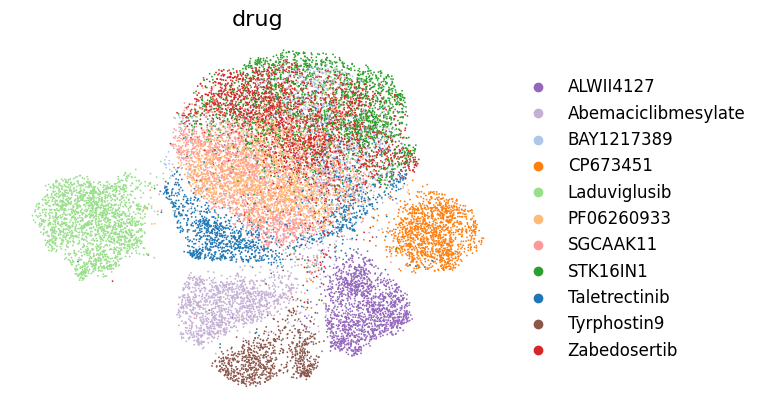

In [72]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z', random_state=0)
sc.tl.umap(sub, random_state=0)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("tab20", n_colors=n_cats)
random.seed(0)
random.shuffle(palette)
sc.pl.umap(sub, color='drug', palette=palette, frameon=False)

# save figures pdf, png, svg

In [39]:
palette = sns.color_palette("hsv", n_colors=2)

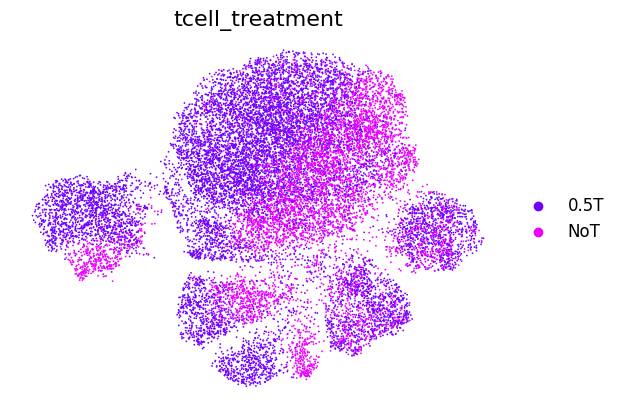

In [58]:
sc.pl.umap(sub, color='tcell_treatment', palette=palette, frameon=False)

In [73]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.750  (p = 4.5e-11)
 Pearson  r = 0.748  (p = 5.2e-11)


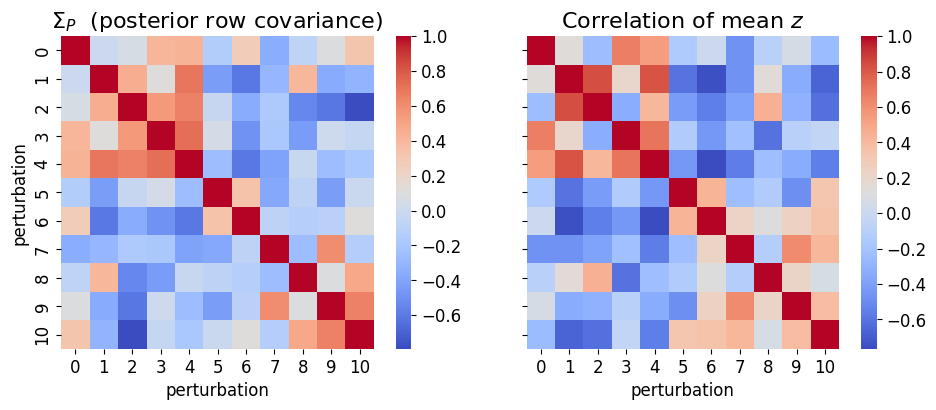

In [60]:
slk.pl.plot_zcorr(data)

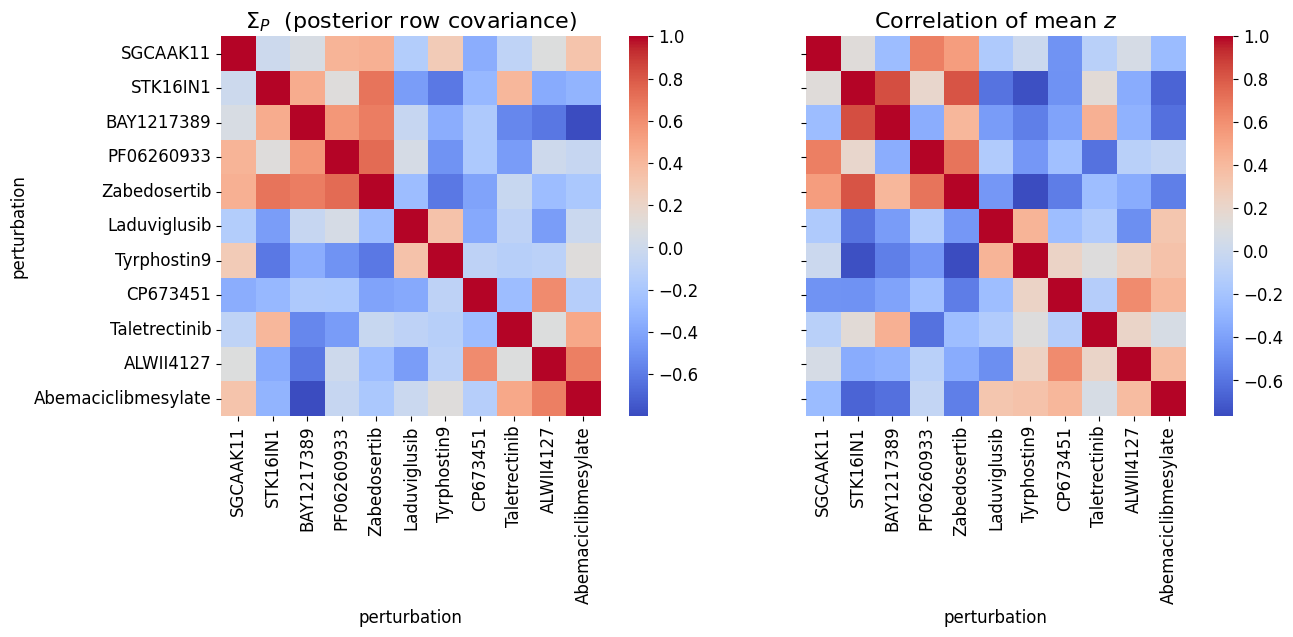

In [74]:
from scipy.cluster.hierarchy import linkage, leaves_list

def plot_zcorr_with_names(adata, uns_key='results'):
    # Get config values
    pert_key = slk.configs.get_config('pert_key')
    ntc_label = slk.configs.get_config('ntc_label')
    
    # Get perturbation names in the same order as the model (sorted unique, excluding NTC)
    # This matches the logic in PerturbMatchingDataset
    pert_vals = adata.obs[pert_key].values
    pert_vals = pert_vals[pert_vals != ntc_label]
    pert_names = np.unique(pert_vals)
    
    # Get matrices
    Sigma_P_posterior = adata.uns[uns_key]['rho_corr']
    Sigma_z = adata.uns[uns_key]['z_corr']

    # Compute clustering order
    link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
    order = leaves_list(link)              # permutation indices, shape (P,)

    # Reorder matrices
    SigmaP_ord = Sigma_P_posterior[order][:, order]
    Sigmaz_ord = Sigma_z[order][:, order]
    
    # Reorder names
    pert_names_ord = pert_names[order]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=axes[0], 
                xticklabels=pert_names_ord, yticklabels=pert_names_ord)
    axes[0].set_title(r"$\Sigma_P$  (posterior row covariance)")
    axes[0].set_xlabel("perturbation")
    axes[0].set_ylabel("perturbation")

    sns.heatmap(Sigmaz_ord, cmap="coolwarm", square=True, ax=axes[1],
                xticklabels=pert_names_ord, yticklabels=pert_names_ord)
    axes[1].set_title("Correlation of mean $z$")
    axes[1].set_xlabel("perturbation")

    plt.tight_layout()
    # plt.savefig(os.path.join(figure_dir, f"{concentration}_correlation.svg"), dpi=300, bbox_inches='tight')
    # plt.savefig(os.path.join(figure_dir, f"{concentration}_correlation.png"), dpi=300, bbox_inches='tight')
    # plt.savefig(os.path.join(figure_dir, f"{concentration}_correlation.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

plot_zcorr_with_names(data)

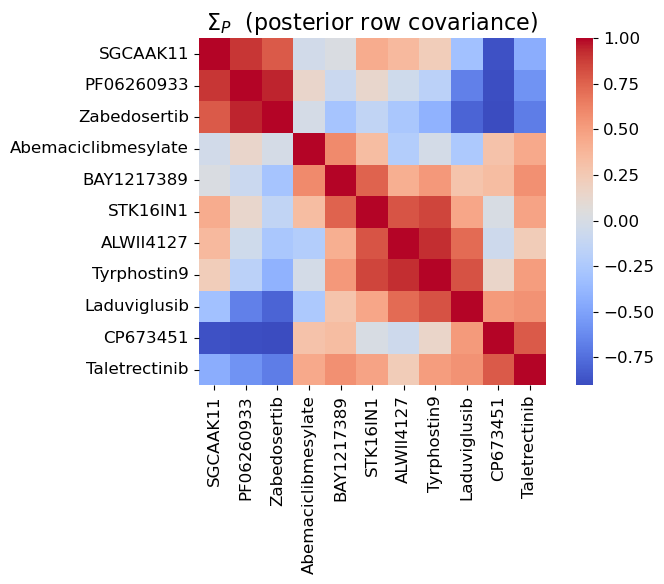

In [44]:
from scipy.cluster.hierarchy import linkage, leaves_list

def plot_zcorr_with_names(adata, uns_key='results'):
    # Get config values
    pert_key = slk.configs.get_config('pert_key')
    ntc_label = slk.configs.get_config('ntc_label')
    
    # Get perturbation names in the same order as the model (sorted unique, excluding NTC)
    # This matches the logic in PerturbMatchingDataset
    pert_vals = adata.obs[pert_key].values
    pert_vals = pert_vals[pert_vals != ntc_label]
    pert_names = np.unique(pert_vals)
    
    # Get matrices
    Sigma_P_posterior = adata.uns[uns_key]['rho_corr']

    # Compute clustering order
    link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
    order = leaves_list(link)              # permutation indices, shape (P,)

    # Reorder matrices
    SigmaP_ord = Sigma_P_posterior[order][:, order]
    
    # Reorder names
    pert_names_ord = pert_names[order]

    # Plot only left heatmap
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=ax, 
                xticklabels=pert_names_ord, yticklabels=pert_names_ord)
    ax.set_title(r"$\Sigma_P$  (posterior row covariance)")
    #ax.set_xlabel("perturbation")
    #ax.set_ylabel("perturbation")

    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f"{concentration}_correlation.svg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{concentration}_correlation.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{concentration}_correlation.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

plot_zcorr_with_names(data)

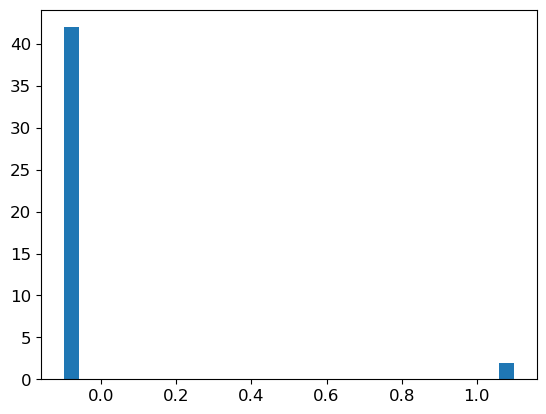

In [45]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)

# save this figure
plt.savefig(os.path.join(figure_dir, f"{concentration}_W_histogram.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_W_histogram.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_W_histogram.pdf"), dpi=300, bbox_inches='tight')     
plt.show()

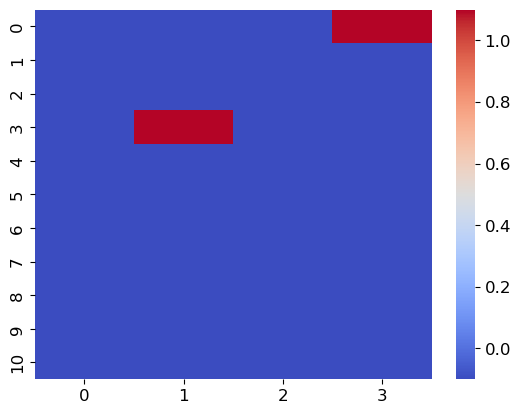

In [46]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

# save this figure
plt.savefig(os.path.join(figure_dir, f"{concentration}_W_heatmap.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_W_heatmap.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_W_heatmap.pdf"), dpi=300, bbox_inches='tight')     

In [47]:
dataset = slk.tl.PerturbMatchingDataset(data)
all_genes = dataset.perturbation_dict.keys()

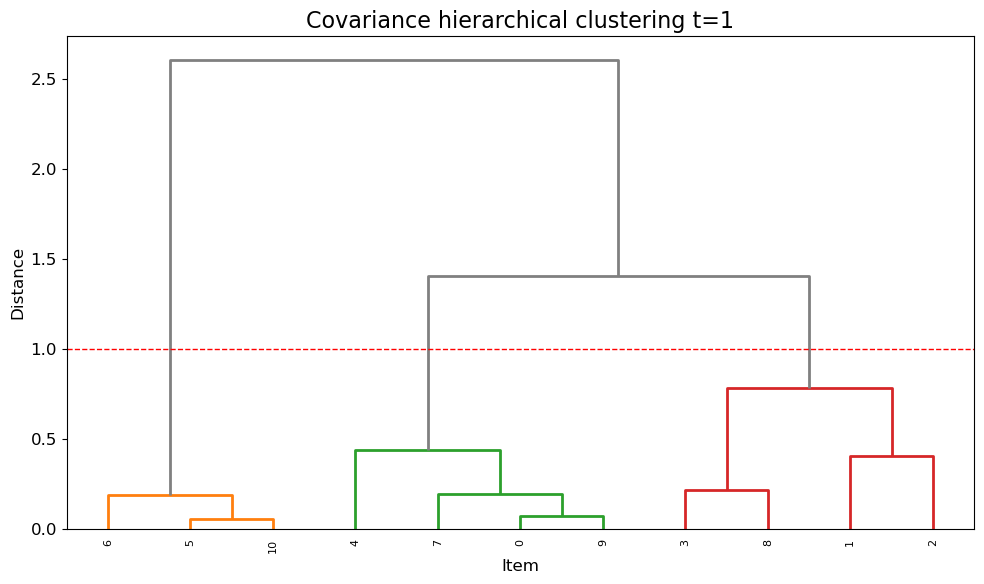

In [48]:
groups = slk.tl.cluster_rho(data, t=1, show=True)

In [49]:
new_colormap = [
    'darkslateblue',  # 0
    'firebrick',      # 1
    'darkorange',     # 2
    'forestgreen',    # 3
    'gold',           # 4
    'dodgerblue',     # 5
    'mediumorchid',   # 6
    'deeppink',       # 7
    'teal',           # 8
    'black'           # 9
]

In [50]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from matplotlib.colors import to_hex
def cluster_rho(adata, t=1.5, uns_key='results', rho_corr=None, show=True, pert_key='perturbation', figure_dir=None, save_name=None):
    if rho_corr is None:
        C = adata.uns[uns_key]['rho_corr']
    else:
        C = rho_corr
    
    # Get perturbation names - try multiple possible locations
    if 'pert_names' in adata.uns.get(uns_key, {}):
        pert_names = adata.uns[uns_key]['pert_names']
    elif 'perts' in adata.uns.get(uns_key, {}):
        pert_names = adata.uns[uns_key]['perts']
    else:
        # Fall back to unique values from obs
        pert_names = adata.obs[pert_key].cat.categories.tolist()
        # Remove control if present
        pert_names = [p for p in pert_names if p.lower() not in ['control', 'ctrl', 'non-targeting']]
    
    D = 1.0 - C  # distance
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    
    if show:
        plt.figure(figsize=(max(3, len(pert_names) * 0.15), 4))
        _ug = sorted(set(fcluster(Z_link, t=t, criterion='distance')))
        _pal = [to_hex(new_colormap[i % len(new_colormap)]) for i in range(len(_ug))]
        set_link_color_palette(_pal)
        ddata_vis = dendrogram(
            Z_link,
            color_threshold=t,
            above_threshold_color="gray",
            labels=pert_names,  # Use actual names
            leaf_rotation=90,
            leaf_font_size=8,
        )
        plt.axhline(y=t, color="#2CA02C", linestyle="--", linewidth=1)
        # Color Tyrphostin9 branch green
        if 'Tyrphostin9' in list(pert_names):
            _t9_pos = ddata_vis['ivl'].index('Tyrphostin9') if 'Tyrphostin9' in ddata_vis['ivl'] else None
            if _t9_pos is not None:
                _t9_x = 5 + _t9_pos * 10
                for line in plt.gca().get_lines():
                    if any(abs(x - _t9_x) < 0.1 for x in line.get_xdata()):
                        line.set_color('#2CA02C')
        #plt.title(f"Covariance hierarchical clustering t={t}")
        plt.xlabel("Perturbations")
        plt.ylabel("Distance")
        plt.tight_layout()
        
        # Export the figures
        if figure_dir and save_name:
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.svg"), dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.png"), dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.pdf"), dpi=300, bbox_inches='tight')
            print(f"Saved figures to {figure_dir}/{save_name}_dendrogram.[svg|png|pdf]")
        
        plt.show()
    
    # Cluster labels at the same cut
    groups = fcluster(Z_link, t=t, criterion='distance')

    # Build group→color mapping using same palette as dendrogram
    unique_groups = sorted(set(groups))
    palette_hex = [to_hex(new_colormap[i % len(new_colormap)]) for i in range(len(unique_groups))]
    set_link_color_palette(palette_hex)
    # Extract leaf colors from dendrogram (no_plot)
    ddata = dendrogram(Z_link, color_threshold=t, above_threshold_color='gray',
                       no_plot=True)
    leaf_colors = ddata.get('leaves_color_list', [])
    group_to_color = {}
    for leaf_idx, color in zip(ddata['leaves'], leaf_colors):
        g = groups[leaf_idx]
        if g not in group_to_color:
            group_to_color[g] = color
    # Store for plot_zcorr_colored
    adata.uns['_dendrogram_colors'] = {str(k): v for k, v in group_to_color.items()}

    cluster_assignments = dict(zip(pert_names, groups))
    return groups, cluster_assignments

In [51]:
cluster_rho(data, t=1, show=True, figure_dir=figure_dir, save_name=f"{pert_type}_{concentration}uM")

ValueError: Dimensions of Z and labels must be consistent.

<Figure size 300x400 with 0 Axes>

In [ ]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
ALWII4127,1
Abemaciclibmesylate,2
BAY1217389,2
CP673451,1
Laduviglusib,2
PF06260933,1
SGCAAK11,3
STK16IN1,3
Taletrectinib,3
Tyrphostin9,3


pert_group
1    5134
2    4361
3    8726
Name: count, dtype: int64


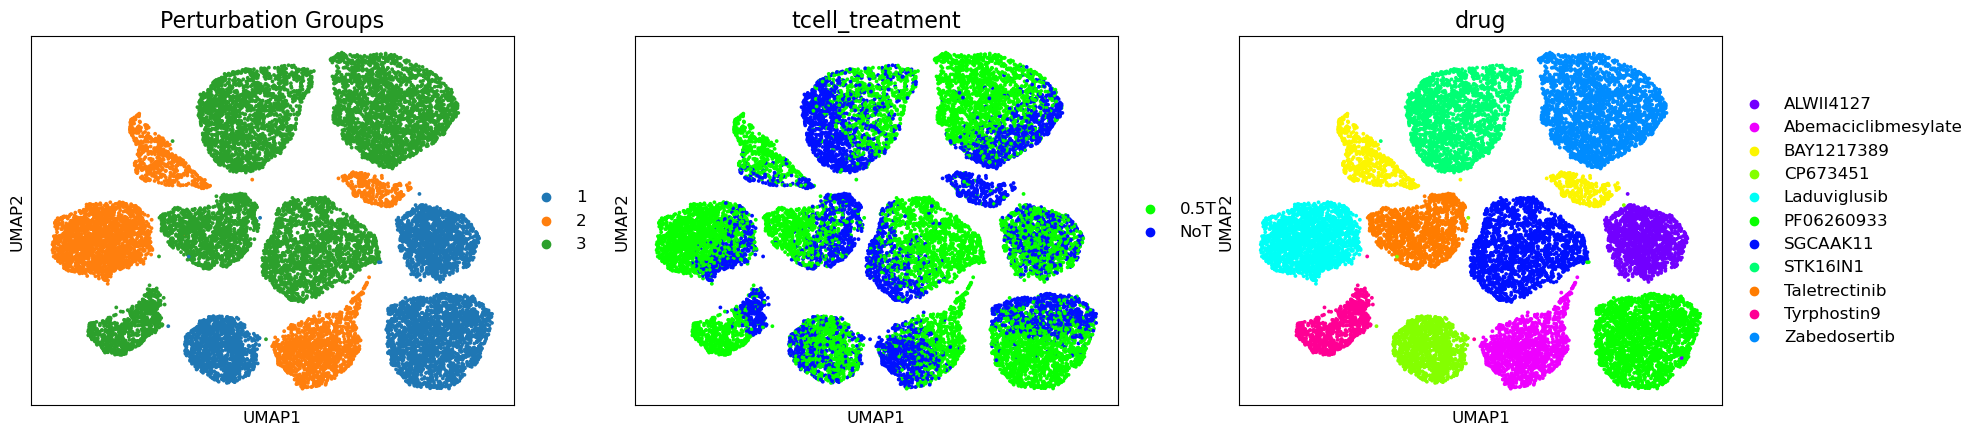

In [ ]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group', 'tcell_treatment','drug'], title='Perturbation Groups', size=30)

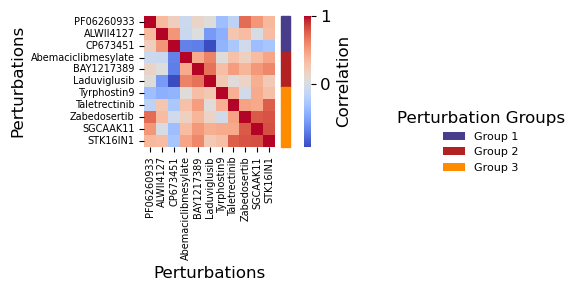

In [ ]:
from __future__ import annotations

from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib import gridspec
from matplotlib.patches import Patch

def plot_zcorr_colored(adata, t=1.5, uns_key='results', show_pert_labels=True, group_color=new_colormap):
    """
    Plot correlation matrices with color bars for each perturbation group.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object with results in adata.uns[uns_key].
    uns_key : str, default 'results'
        Key in adata.uns where results are stored.
    show_pert_labels : bool, default True
        Whether to show perturbation labels on axes.
    group_col : str, default 'pert_group'
        Column in adata.obs containing perturbation groups.
    """
    
    Sigma_P_posterior = adata.uns[uns_key]['rho_corr']
    Sigma_z = adata.uns[uns_key]['z_corr']
    pert_names = adata.uns[uns_key]['perts']

    # Same linkage as cluster_rho: ward on distance matrix
    from scipy.cluster.hierarchy import fcluster
    D = 1.0 - Sigma_P_posterior
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    order = leaves_list(Z_link)

    # Apply ordering to both matrices
    SigmaP_ord = Sigma_P_posterior[order][:, order]
    Sigmaz_ord = Sigma_z[order][:, order]
    pert_names_ord = pert_names[order]

    # Same color logic as cluster_rho
    from scipy.cluster.hierarchy import fcluster, set_link_color_palette, dendrogram
    from matplotlib.colors import to_hex
    groups = fcluster(Z_link, t=t, criterion='distance')
    groups_ord = groups[order]
    unique_groups = sorted(set(groups_ord))
    # Set same palette as cluster_rho
    palette_hex = [to_hex(group_color[i % len(group_color)]) for i in range(len(unique_groups))]
    set_link_color_palette(palette_hex)
    # Extract leaf→color via dendrogram (no_plot)
    ddata = dendrogram(Z_link, color_threshold=t, above_threshold_color='#2CA02C', no_plot=True)
    leaf_colors = ddata.get('leaves_color_list', [])
    group_to_color = {}
    for leaf_idx, color in zip(ddata['leaves'], leaf_colors):
        g = groups[leaf_idx]
        if g not in group_to_color:
            group_to_color[g] = color
    # Fallback if leaves_color_list unavailable
    for grp in unique_groups:
        if grp not in group_to_color:
            group_to_color[grp] = palette_hex[unique_groups.index(grp)]
    row_colors = [group_to_color[grp] for grp in groups_ord]
    
    n_perts = len(pert_names_ord)

    # Thickness controls for color bars
    #top_bar_height =0   # was 0.5
    side_bar_width = 0.8   # was 0.5

    # Plot single heatmap
    fig = plt.figure(figsize=(4, 3))
    ax0 = fig.add_subplot(111)
    
    sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=ax0, 
                xticklabels=pert_names_ord if show_pert_labels else False,
                yticklabels=pert_names_ord if show_pert_labels else False,
                cbar_kws={'label': 'Correlation', 'pad': 0.15})
    ax0.set_title("")
    ax0.set_xlabel("Perturbations")
    ax0.set_ylabel("Perturbations")

    # Make font size smaller
    if show_pert_labels:
        ax0.set_xticklabels(ax0.get_xticklabels(), fontsize=7)
        ax0.set_yticklabels(ax0.get_yticklabels(), fontsize=7)
    
    gap = 0.5  # space between heatmap and group color strip

    # Add color bar on right (thicker)
    for i, color in enumerate(row_colors):
        # Top
        #ax0.add_patch(plt.Rectangle((i, -0.5), 1, top_bar_height, color=color, 
                                    #transform=ax0.transData, clip_on=False))
        # Right
        ax0.add_patch(plt.Rectangle((n_perts + gap, i), side_bar_width, 1, color=color, 
                                    transform=ax0.transData, clip_on=False))

    # Create legend outside with transparent background
    legend_elements = [Patch(facecolor=group_to_color[grp], label=f'Group {grp}') 
                      for grp in unique_groups]
    fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        title='Perturbation Groups',
        fontsize=8,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_correlation_color.svg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_correlation_color.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_correlation_color.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

plot_zcorr_colored(sub, t=1)



In [53]:
palette1 = [
"#FFD166",  
"#023047",  
]

palette2 = [
    "#EF476F", "#0077B6", "#8338EC", "#FB5607",  "#F7A1C4",
    "#00D9FF", "#38A169", "#8B5E3C", "#4A5568", "#2EC4B6", "#9B2226"
]

palette2_very_light = [
    "#EF476F",  # keep
    "#A8D8F0",  # very light blue
    "#D6C7FA",  # very light purple
    "#FB5607",  # keep
    "#FDD9E7",  # very light pink
    "#CFF5FF",  # very light cyan
    "#CDEEDD",  # very light green
    "#E3D2C4",  # very light brown
    "#D6DEE8",  # very light gray-blue
    "#CFF1EA",  # very light teal
    "#E8B3B3"   # very light dark red
]



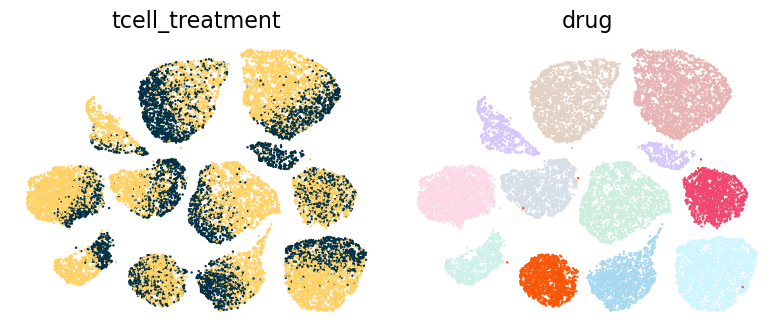

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

sc.pl.umap(sub, color='tcell_treatment', title='tcell_treatment', 
           palette=palette1, size=12, frameon=False, ax=axes[0], show=False,legend_loc=None)

sc.pl.umap(sub, color='drug', title='drug', 
           palette=palette2_very_light, size=12, frameon=False, ax=axes[1], show=False,legend_loc=None)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{concentration}_sherlock_zspace.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_sherlock_zspace.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_sherlock_zspace.pdf"), dpi=300, bbox_inches='tight')
plt.show()

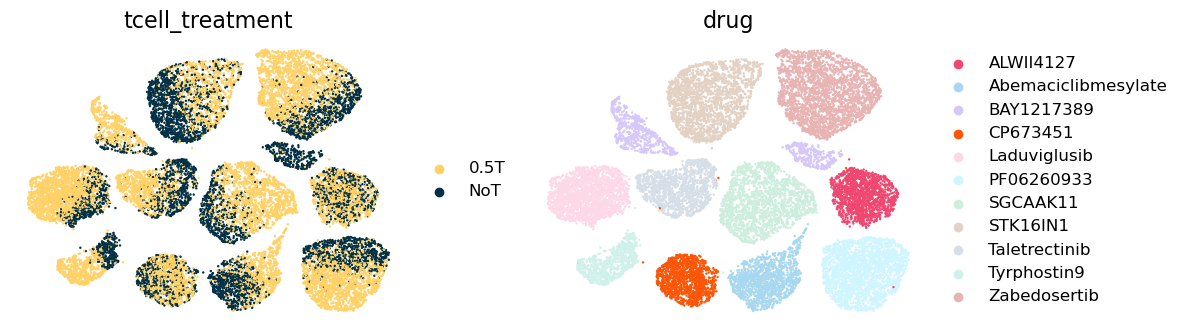

In [55]:

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

sc.pl.umap(sub, color='tcell_treatment', title='tcell_treatment', 
           palette=palette1, size=12, frameon=False, ax=axes[0], show=False)

sc.pl.umap(sub, color='drug', title='drug', 
           palette=palette2_very_light, size=12, frameon=False, ax=axes[1], show=False)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{concentration}_sherlock_zspace_with_legends.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_sherlock_zspace_with_legends.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_sherlock_zspace_with_legends.pdf"), dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# Print gene symbols per group, one gene per line (no quotation marks)
grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())

for grp in sorted(grouped.index):
    print(f"Group {grp}:")
    for gene in grouped.loc[grp]:
        print(gene)
    print()

Group 1:
ALWII4127
CP673451
PF06260933

Group 2:
Abemaciclibmesylate
BAY1217389
Laduviglusib

Group 3:
SGCAAK11
STK16IN1
Taletrectinib
Tyrphostin9
Zabedosertib



/tmp/ipykernel_449962/2222304912.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())


In [57]:
pert_key="drug"
ntc_label="DMSO"
treatment_key='tcell_treatment'

In [58]:
# Get perturbation and condition names
# Extract names
pert_names = list(data.uns['results']['perts'])    # matches cfs_mat axis 0
cond_names = list(data.uns['results']['conditions'])  # matches cfs_mat axes 1 and 2

# Get the matrix
cfs_mat = data.uns['results']['condition_perturbation_interaction']  # shape: (P, C, C)

# Verify dimensions match
assert cfs_mat.shape[0] == len(pert_names)
assert cfs_mat.shape[1] == len(cond_names)
assert cfs_mat.shape[2] == len(cond_names)

In [59]:
# Average shift per perturbation (across all condition pairs)
mask = np.triu(np.ones((len(cond_names), len(cond_names))), k=1).astype(bool)
avg_shift_per_pert = np.array([cfs_mat[p][mask].mean() for p in range(len(pert_names))])

# Rank perturbations by context-dependency
df_pert_sensitivity = pd.DataFrame({
    'perturbation': pert_names,
    'condition_effect_on_perturbation': avg_shift_per_pert,
}).sort_values('condition_effect_on_perturbation', ascending=False)

In [60]:
# Save df_pert_sensitivity for cross-concentration comparison
df_pert_sensitivity.to_csv(
    os.path.join(figure_dir, f'{concentration}um_pert_sensitivity.csv'),
    index=False
)
print(f'Saved {concentration}um_pert_sensitivity.csv')

Saved 10um_pert_sensitivity.csv


/tmp/ipykernel_449962/2997926270.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pert_sensitivity, x='perturbation', y='condition_effect_on_perturbation', palette=bar_colors)
/tmp/ipykernel_449962/2997926270.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


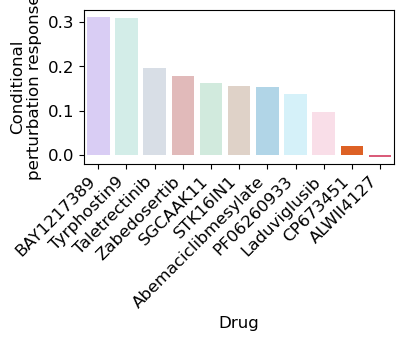

In [61]:
# plot bar plot of condition effect on perturbation
plt.figure(figsize=(4, 2))

if hasattr(data.obs['drug'], 'cat'):
    drug_order = [drug for drug in data.obs['drug'].cat.categories if drug != 'DMSO']
else:
    drug_order = sorted([drug for drug in data.obs['drug'].unique() if drug != 'DMSO'])

drug_to_color = dict(zip(drug_order, palette2_very_light))
bar_colors = [drug_to_color.get(drug, 'gray') for drug in df_pert_sensitivity['perturbation']]

sns.barplot(data=df_pert_sensitivity, x='perturbation', y='condition_effect_on_perturbation', palette=bar_colors)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Drug')
plt.ylabel('Conditional\nperturbation response')
#plt.title('Condition Effect on \nPerturbation by Drug')
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{concentration}_condition_effect_on_perturbation.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_condition_effect_on_perturbation.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_condition_effect_on_perturbation.pdf"), dpi=300, bbox_inches='tight')
plt.show()


In [62]:
df_pert_sensitivity

,perturbation,condition_effect_on_perturbation
2,BAY1217389,0.312028
9,Tyrphostin9,0.308868
8,Taletrectinib,0.195802
10,Zabedosertib,0.177218
6,SGCAAK11,0.161151
7,STK16IN1,0.155206
1,Abemaciclibmesylate,0.153007
5,PF06260933,0.137360
4,Laduviglusib,0.097618
3,CP673451,0.019576


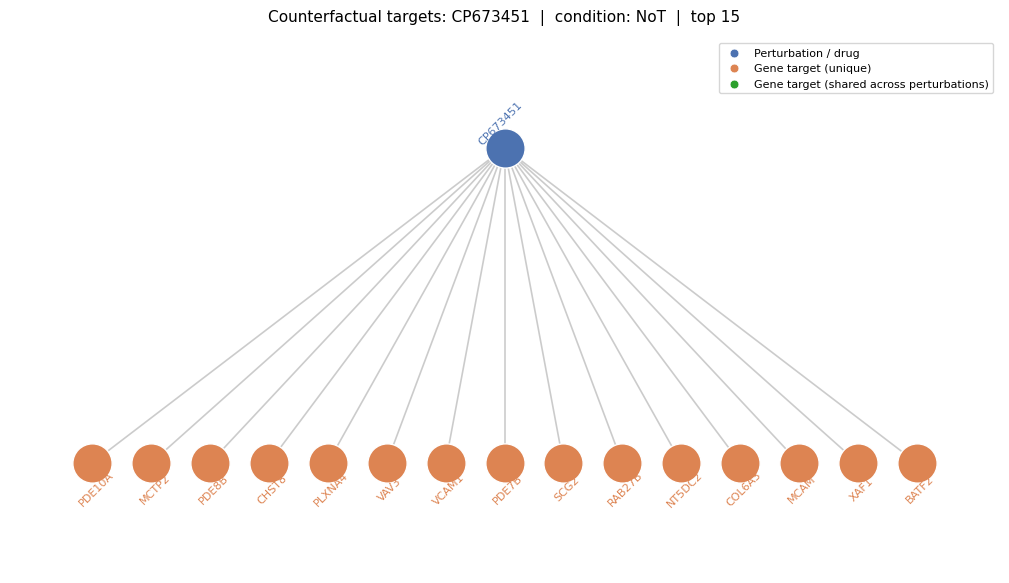

In [63]:
slk.pl.plot_cf_bipartite(
    data,
    cond_idx=0,          
    pert_name="CP673451",     
    top_n=15,            # top N target genes by effect size
)

  cond 0: 7569/31834 (pert,gene) pairs pass qval<0.05
Saved 10_cf_bipartite_CP673451_ALWII4127_NoT.svg/png/pdf


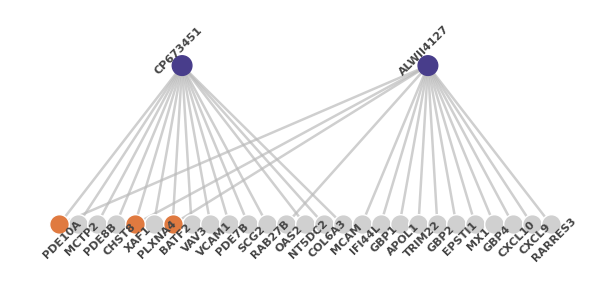

  cond 1: 6649/31834 (pert,gene) pairs pass qval<0.05
Saved 10_cf_bipartite_CP673451_ALWII4127_0.5T.svg/png/pdf


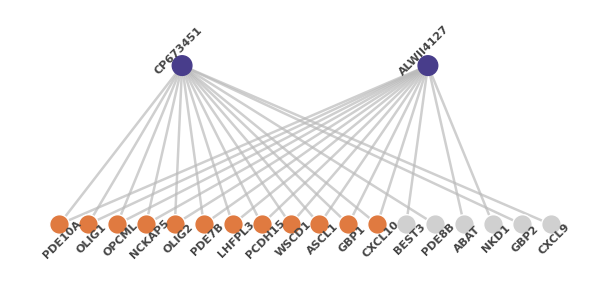

In [66]:
# --- Publication-ready save for plot_cf_bipartite (figure_1 style) — all conditions ---
from matplotlib.collections import LineCollection
from unittest.mock import patch
import sherlock.plotting._simple as _slk_simple

PERT_X_MARGIN = 0.25  # 0=full spread, 0.5=fully centered
_orig_draw_bipartite = _slk_simple._draw_bipartite_nx

def _centered_draw_bipartite(pert_nodes, gene_nodes, edges, ax, **kwargs):
    n_p, n_g = len(pert_nodes), len(gene_nodes)
    if n_p == 1:
        orig_pert_xs = [0.5]
        new_pert_xs  = [0.5]
    else:
        orig_pert_xs = [i / (n_p - 1) for i in range(n_p)]
        new_pert_xs  = [PERT_X_MARGIN + i * (1 - 2*PERT_X_MARGIN) / (n_p - 1) for i in range(n_p)]
    x_remap = dict(zip(orig_pert_xs, new_pert_xs))
    _orig_draw_bipartite(pert_nodes, gene_nodes, edges, ax,
                         pert_color='#26547c',
                         gene_color='#D0D0D0',
                         gene_overlap_color='#E07A40',
                         **kwargs)
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue
        if np.all(offsets[:, 1] == 1.0) and len(offsets) == n_p:
            coll.set_offsets(np.column_stack([new_pert_xs, np.ones(n_p)]))
    for txt, x in zip(ax.texts[:n_p], new_pert_xs):
        _, old_y = txt.get_position()
        txt.set_position((x, old_y))
    for coll in ax.collections:
        if not isinstance(coll, LineCollection):
            continue
        segs = coll.get_segments()
        new_segs = []
        for seg in segs:
            new_seg = []
            for pt in seg:
                x, y = pt
                if y == 1.0:
                    closest = min(orig_pert_xs, key=lambda ox: abs(ox - x))
                    x = x_remap.get(closest, x)
                new_seg.append([x, y])
            new_segs.append(new_seg)
        coll.set_segments(new_segs)

# Build pert→group color mapping (same clustering as plot_zcorr_colored)
from scipy.cluster.hierarchy import fcluster, set_link_color_palette, dendrogram
from matplotlib.colors import to_hex
_rho = data.uns['results']['rho_corr']
_pnames = data.uns['results']['perts']
_D = 1.0 - _rho
_Z = linkage(_D[np.triu_indices_from(_D, 1)], method='ward')
_groups = fcluster(_Z, t=1, criterion='distance')
_ugrps = sorted(set(_groups))
_pal = [to_hex(new_colormap[i % len(new_colormap)]) for i in range(len(_ugrps))]
set_link_color_palette(_pal)
_ddata = dendrogram(_Z, color_threshold=1, above_threshold_color='#2CA02C', no_plot=True)
_g2c = {}
for _li, _lc in zip(_ddata['leaves'], _ddata.get('leaves_color_list', [])):
    if _groups[_li] not in _g2c:
        _g2c[_groups[_li]] = _lc
for _grp, _col in zip(_ugrps, _pal):
    _g2c.setdefault(_grp, _col)
pert_to_color = {n: _g2c[g] for n, g in zip(_pnames, _groups)}

cond_labels = data.uns['results']['conditions']
_orig_get_cf_data = _slk_simple._get_cf_data

def _make_qval_masked_cf(qv, cidx):
    def _fn(adata, uns_key='results', cf_key='counterfactual_effect_size'):
        cf, perts, genes = _orig_get_cf_data(adata, uns_key=uns_key, cf_key=cf_key)
        cf = cf.copy()
        cf[cidx][qv >= 0.05] = 0.0
        n_sig = int((qv < 0.05).sum())
        print(f'  cond {cidx}: {n_sig}/{qv.size} (pert,gene) pairs pass qval<0.05')
        return cf, perts, genes
    return _fn

for cond_idx in range(len(cond_labels)):
    cond_label = cond_labels[cond_idx]
    _qvals = np.asarray(data.uns['results']['ev_results'][cond_idx]['qvals'], dtype=float)  # (P, G)
    _cf_fig = {}
    def _show_capture():
        _cf_fig['fig'] = plt.gcf()
    with patch.object(_slk_simple, '_draw_bipartite_nx', _centered_draw_bipartite), \
         patch.object(_slk_simple, '_get_cf_data', _make_qval_masked_cf(_qvals, cond_idx)), \
         patch.object(plt, 'show', _show_capture):
        slk.pl.plot_cf_bipartite(
            data,
            cond_idx=cond_idx,
            pert_name=["CP673451", "ALWII4127"],
            top_n=15,
            min_effect=1e-10,
            figsize=(6, 2.8),
        )
    fig = _cf_fig['fig']
    ax = fig.axes[0]
    ax.set_title('')  # Remove title
    for coll in ax.collections:
        if isinstance(coll, LineCollection):
            coll.set_color('#BBBBBB')
            coll.set_linewidth(1.8)
            coll.set_alpha(0.7)
    for txt in ax.texts:
        txt.set_fontsize(8)
        txt.set_color('#444444')
        txt.set_fontweight('bold')
    # Shrink node circles
    for coll in ax.collections:
        if not isinstance(coll, LineCollection):
            sizes = coll.get_sizes()
            if len(sizes) > 0:
                coll.set_sizes([200])
    legend = ax.get_legend()
    if legend:
        legend.remove()
    # Color pert nodes by their group color
    _pert_list = ["CP673451", "ALWII4127"]
    _node_colors = [pert_to_color.get(p, '#26547c') for p in _pert_list]
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue
        if np.all(offsets[:, 1] == 1.0) and len(offsets) == len(_pert_list):
            coll.set_facecolor(_node_colors)
            coll.set_edgecolor(_node_colors)
    plt.tight_layout(pad=0.3)
    save_name = f"{concentration}_cf_bipartite_CP673451_ALWII4127_{cond_label}"
    for ext in ('svg', 'png', 'pdf'):
        fig.savefig(os.path.join(figure_dir, f'{save_name}.{ext}'), dpi=300, bbox_inches='tight', transparent=True)
    print(f'Saved {save_name}.svg/png/pdf')
    plt.show()


  cond 0: 7569/31834 (pert,gene) pairs pass qval<0.05
Saved 10_cf_bipartite_CP673451_BAY1217389_NoT.svg/png/pdf


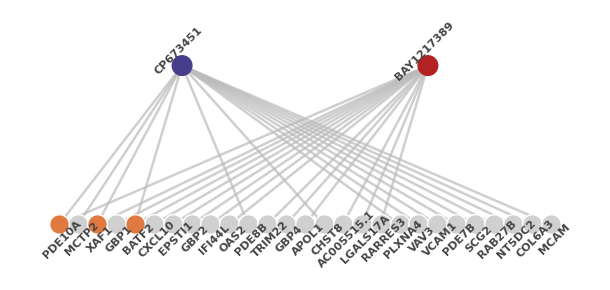

  cond 1: 6649/31834 (pert,gene) pairs pass qval<0.05
Saved 10_cf_bipartite_CP673451_BAY1217389_0.5T.svg/png/pdf


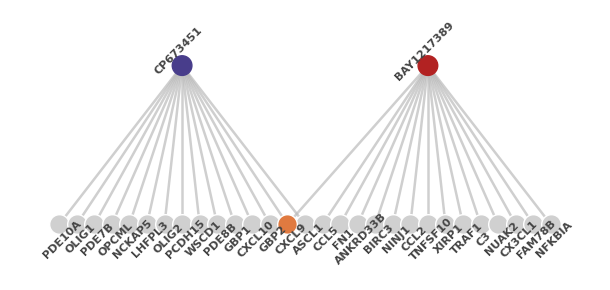

In [70]:
# --- Publication-ready save for plot_cf_bipartite (figure_1 style) — all conditions ---
from matplotlib.collections import LineCollection
from unittest.mock import patch
import sherlock.plotting._simple as _slk_simple

PERT_X_MARGIN = 0.25  # 0=full spread, 0.5=fully centered
_orig_draw_bipartite = _slk_simple._draw_bipartite_nx

def _centered_draw_bipartite(pert_nodes, gene_nodes, edges, ax, **kwargs):
    n_p, n_g = len(pert_nodes), len(gene_nodes)
    if n_p == 1:
        orig_pert_xs = [0.5]
        new_pert_xs  = [0.5]
    else:
        orig_pert_xs = [i / (n_p - 1) for i in range(n_p)]
        new_pert_xs  = [PERT_X_MARGIN + i * (1 - 2*PERT_X_MARGIN) / (n_p - 1) for i in range(n_p)]
    x_remap = dict(zip(orig_pert_xs, new_pert_xs))
    _orig_draw_bipartite(pert_nodes, gene_nodes, edges, ax,
                         pert_color='#26547c',
                         gene_color='#D0D0D0',
                         gene_overlap_color='#E07A40',
                         **kwargs)
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue
        if np.all(offsets[:, 1] == 1.0) and len(offsets) == n_p:
            coll.set_offsets(np.column_stack([new_pert_xs, np.ones(n_p)]))
    for txt, x in zip(ax.texts[:n_p], new_pert_xs):
        _, old_y = txt.get_position()
        txt.set_position((x, old_y))
    for coll in ax.collections:
        if not isinstance(coll, LineCollection):
            continue
        segs = coll.get_segments()
        new_segs = []
        for seg in segs:
            new_seg = []
            for pt in seg:
                x, y = pt
                if y == 1.0:
                    closest = min(orig_pert_xs, key=lambda ox: abs(ox - x))
                    x = x_remap.get(closest, x)
                new_seg.append([x, y])
            new_segs.append(new_seg)
        coll.set_segments(new_segs)

# Build pert→group color mapping (same clustering as plot_zcorr_colored)
from scipy.cluster.hierarchy import fcluster, set_link_color_palette, dendrogram
from matplotlib.colors import to_hex
_rho = data.uns['results']['rho_corr']
_pnames = data.uns['results']['perts']
_D = 1.0 - _rho
_Z = linkage(_D[np.triu_indices_from(_D, 1)], method='ward')
_groups = fcluster(_Z, t=1, criterion='distance')
_ugrps = sorted(set(_groups))
_pal = [to_hex(new_colormap[i % len(new_colormap)]) for i in range(len(_ugrps))]
set_link_color_palette(_pal)
_ddata = dendrogram(_Z, color_threshold=1, above_threshold_color='#2CA02C', no_plot=True)
_g2c = {}
for _li, _lc in zip(_ddata['leaves'], _ddata.get('leaves_color_list', [])):
    if _groups[_li] not in _g2c:
        _g2c[_groups[_li]] = _lc
for _grp, _col in zip(_ugrps, _pal):
    _g2c.setdefault(_grp, _col)
pert_to_color = {n: _g2c[g] for n, g in zip(_pnames, _groups)}

cond_labels = data.uns['results']['conditions']
_orig_get_cf_data = _slk_simple._get_cf_data

def _make_qval_masked_cf(qv, cidx):
    def _fn(adata, uns_key='results', cf_key='counterfactual_effect_size'):
        cf, perts, genes = _orig_get_cf_data(adata, uns_key=uns_key, cf_key=cf_key)
        cf = cf.copy()
        cf[cidx][qv >= 0.05] = 0.0
        n_sig = int((qv < 0.05).sum())
        print(f'  cond {cidx}: {n_sig}/{qv.size} (pert,gene) pairs pass qval<0.05')
        return cf, perts, genes
    return _fn

for cond_idx in range(len(cond_labels)):
    cond_label = cond_labels[cond_idx]
    _qvals = np.asarray(data.uns['results']['ev_results'][cond_idx]['qvals'], dtype=float)  # (P, G)
    _cf_fig = {}
    def _show_capture():
        _cf_fig['fig'] = plt.gcf()
    with patch.object(_slk_simple, '_draw_bipartite_nx', _centered_draw_bipartite), \
         patch.object(_slk_simple, '_get_cf_data', _make_qval_masked_cf(_qvals, cond_idx)), \
         patch.object(plt, 'show', _show_capture):
        slk.pl.plot_cf_bipartite(
            data,
            cond_idx=cond_idx,
            pert_name=["CP673451", "BAY1217389"],
            top_n=15,
            min_effect=1e-10,
            figsize=(6, 2.8),
        )
    fig = _cf_fig['fig']
    ax = fig.axes[0]
    ax.set_title('')  # Remove title
    for coll in ax.collections:
        if isinstance(coll, LineCollection):
            coll.set_color('#BBBBBB')
            coll.set_linewidth(1.8)
            coll.set_alpha(0.7)
    for txt in ax.texts:
        txt.set_fontsize(8)
        txt.set_color('#444444')
        txt.set_fontweight('bold')
    # Shrink node circles
    for coll in ax.collections:
        if not isinstance(coll, LineCollection):
            sizes = coll.get_sizes()
            if len(sizes) > 0:
                coll.set_sizes([200])
    legend = ax.get_legend()
    if legend:
        legend.remove()
    # Color pert nodes by their group color
    _pert_list = ["CP673451", "BAY1217389"]
    _node_colors = [pert_to_color.get(p, '#26547c') for p in _pert_list]
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue
        if np.all(offsets[:, 1] == 1.0) and len(offsets) == len(_pert_list):
            coll.set_facecolor(_node_colors)
            coll.set_edgecolor(_node_colors)
    plt.tight_layout(pad=0.3)
    save_name = f"{concentration}_cf_bipartite_CP673451_BAY1217389_{cond_label}"
    for ext in ('svg', 'png', 'pdf'):
        fig.savefig(os.path.join(figure_dir, f'{save_name}.{ext}'), dpi=300, bbox_inches='tight', transparent=True)
    print(f'Saved {save_name}.svg/png/pdf')
    plt.show()


Saved 10_cf_bipartite_legend.svg/png/pdf


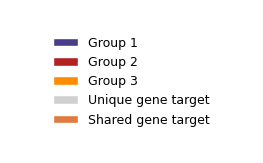

In [169]:

# Build group color legend entries dynamically from clustering
legend_elements = [
    Patch(facecolor=_g2c[grp], edgecolor='white', label=f'Group {grp}')
    for grp in sorted(_g2c)
] + [
    Patch(facecolor='#D0D0D0', edgecolor='white', label='Unique gene target'),
    Patch(facecolor='#E07A40', edgecolor='white', label='Shared gene target'),
]

fig, ax = plt.subplots(figsize=(2.5, 1.5))
ax.legend(handles=legend_elements, loc='center', frameon=False, fontsize=9)
ax.axis('off')
plt.tight_layout(pad=0.2)

save_name = f"{concentration}_cf_bipartite_legend"
for ext in ('svg', 'png', 'pdf'):
    fig.savefig(os.path.join(figure_dir, f'{save_name}.{ext}'), dpi=300, bbox_inches='tight')
print(f'Saved {save_name}.svg/png/pdf')
plt.show()



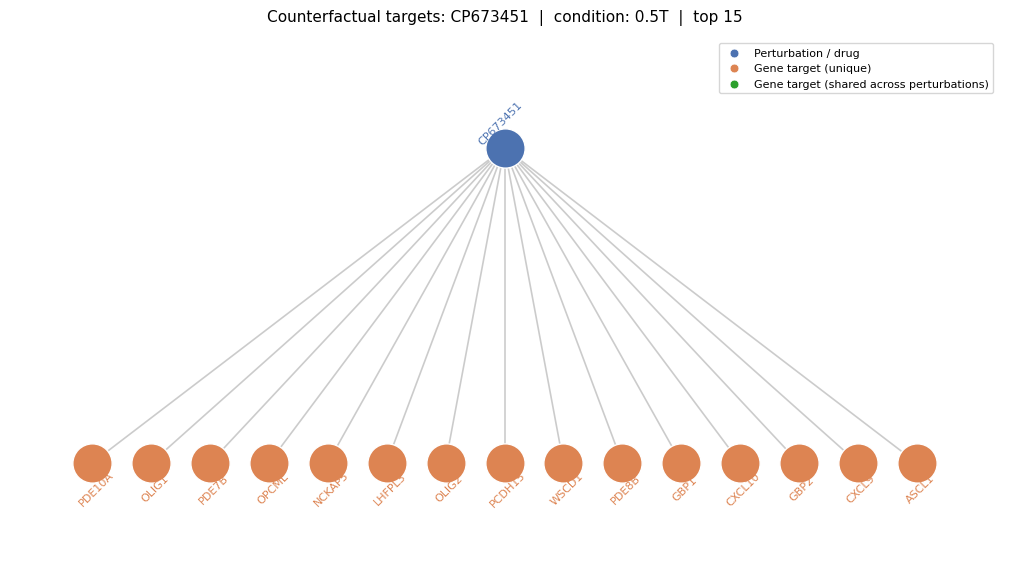

In [170]:
slk.pl.plot_cf_bipartite(
    data,
    cond_idx=1,          
    pert_name="CP673451",     
    top_n=15,            # top N target genes by effect size
)

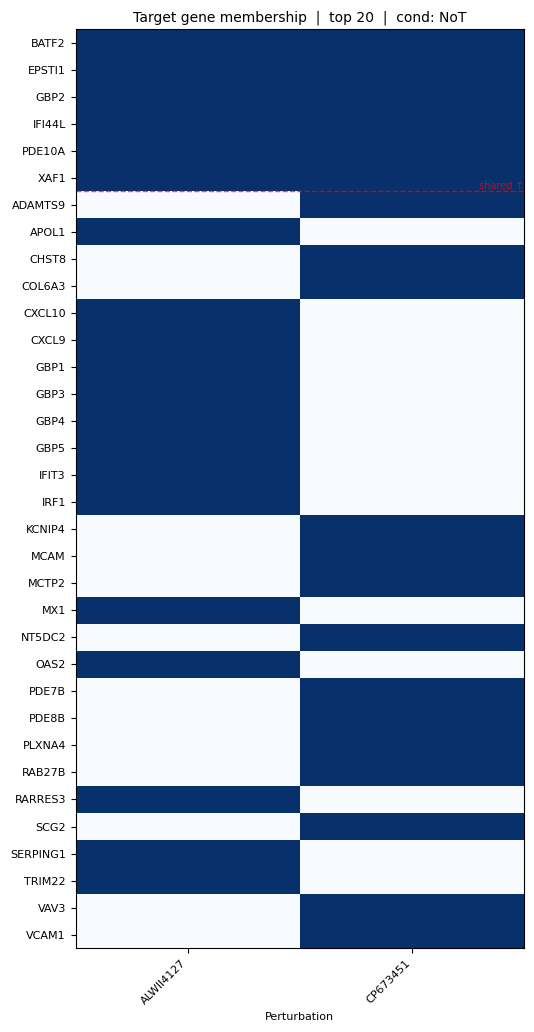

In [171]:
slk.pl.plot_cf_target_overlap(
    data,
    cond_idx=0,
    top_n=20,
    pert_names=["CP673451", "ALWII4127"],  # subset; None = all
    show_jaccard=False,      # pairwise Jaccard similarity heatmap
    show_membership=True,   # gene × drug binary matrix
)

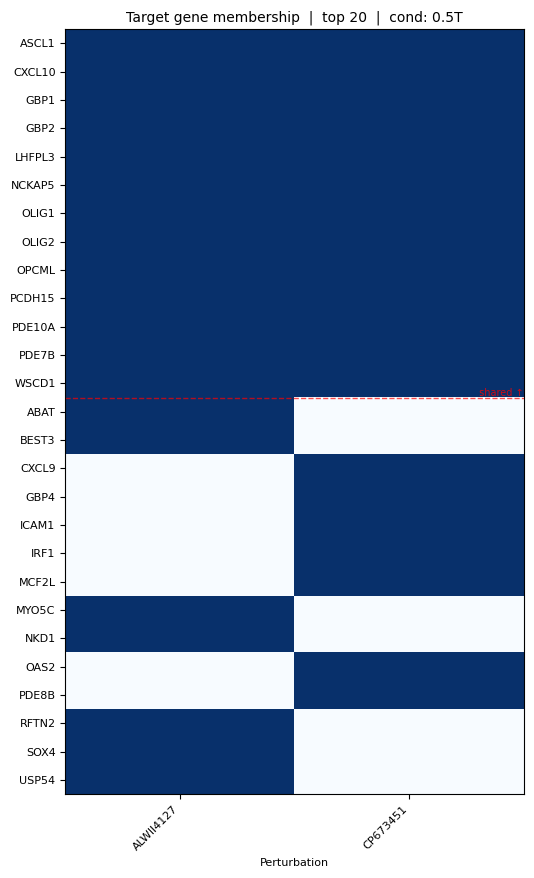

In [172]:
slk.pl.plot_cf_target_overlap(
    data,
    cond_idx=1,
    top_n=20,
    pert_names=["CP673451", "ALWII4127"],  # subset; None = all
    show_jaccard=False,      # pairwise Jaccard similarity heatmap
    show_membership=True,   # gene × drug binary matrix
)

Saved CP673451_ALWII4127_sensitivity_comparison.svg/png/pdf


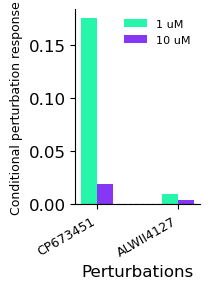

In [173]:
# --- Side-by-side comparison: CP673451 & ALWII4127 across concentrations ---
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DRUGS = ["CP673451", "ALWII4127"]

# Load both concentrations — run save cell in 1um notebook first
path_1um  = os.path.join(figure_dir, '1um_pert_sensitivity.csv')
path_10um = os.path.join(figure_dir, '10um_pert_sensitivity.csv')
missing = [p for p in [path_1um, path_10um] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        f'Missing CSV(s): {missing}\n'
        'Run the df_pert_sensitivity save cell in each notebook first.'
    )
df_1um  = pd.read_csv(path_1um)
df_10um = pd.read_csv(path_10um)

df_1um['concentration']  = '1 uM'
df_10um['concentration'] = '10 uM'
df_all = pd.concat([df_1um, df_10um], ignore_index=True)
# Ensure numeric and take absolute value for comparison
df_all['condition_effect_on_perturbation'] = pd.to_numeric(df_all['condition_effect_on_perturbation'], errors='coerce')
df_all['condition_effect_on_perturbation'] = np.abs(df_all['condition_effect_on_perturbation'])
df_plot = df_all[df_all['perturbation'].isin(DRUGS)].copy()

# Grouped bar plot
concs  = ['1 uM', '10 uM']
x      = np.arange(len(DRUGS))
width  = 0.2
colors = ['#00f59b', '#7014f2']

fig, ax = plt.subplots(figsize=(2, 2.8))
for j, (conc, color) in enumerate(zip(concs, colors)):
    vals = [
        df_plot.loc[(df_plot['perturbation'] == d) & (df_plot['concentration'] == conc),
                    'condition_effect_on_perturbation'].values
        for d in DRUGS
    ]
    vals = [v[0] if len(v) > 0 else 0.0 for v in vals]
    ax.bar(x + j * width - width/2, vals, width, label=conc, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(DRUGS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Conditional perturbation response', fontsize=9)
ax.set_xlabel('Perturbations', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=8, frameon=False)
sns.despine(ax=ax)
plt.tight_layout(pad=0.3)

save_name = 'CP673451_ALWII4127_sensitivity_comparison'
for ext in ('svg', 'png', 'pdf'):
    fig.savefig(os.path.join(figure_dir, f'{save_name}.{ext}'), dpi=300, bbox_inches='tight')
print(f'Saved {save_name}.svg/png/pdf')
plt.show()
